# Basic Measures — Structural Analysis

Four graphs derived from the UniPi corpus (year threshold 2020).

**Graphs:**
- **Combined (weighted)**: direct citation + BC Jaccard (α=0.35)
- **Combined (unweighted)**: same topology, weights removed
- **Citation (undirected)**: direct citations only
- **Citation (directed)**: direct citations, edge direction preserved

In [1]:
import os, gc, time, pickle, random
from collections import Counter, defaultdict

import networkx as nx
import networkit as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.ndimage import uniform_filter1d

out_dir   = "./output"
input_dir = "../00_graph_construction/output/graphs"
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
})

COLORS = {
    'bc_w'  : 'tab:blue',   'bc_uw' : 'steelblue',
    'cit_ud': 'tab:orange',  'cit_d' : 'darkorange',
}
NAMES = {
    'bc_w'  : 'Combined (weighted)',   'bc_uw' : 'Combined (unweighted)',
    'cit_ud': 'Citation (undirected)', 'cit_d' : 'Citation (directed)',
}

In [2]:
with open(os.path.join(input_dir, "graph_combined_2020.gpickle"), "rb") as f:
    G_combined_w = pickle.load(f)
with open(os.path.join(input_dir, "graph_internal_2020.gpickle"), "rb") as f:
    G_cit_d = pickle.load(f)

G_combined_uw = nx.Graph()
G_combined_uw.add_nodes_from(G_combined_w.nodes(data=True))
G_combined_uw.add_edges_from(G_combined_w.edges())
G_cit_ud = G_cit_d.to_undirected()

graphs = {
    'bc_w': G_combined_w, 'bc_uw': G_combined_uw,
    'cit_ud': G_cit_ud,   'cit_d': G_cit_d,
}

print("Graphs loaded:")
for k, G in graphs.items():
    print(f"  {NAMES[k]:<28} {G.number_of_nodes():>7,} nodes  {G.number_of_edges():>9,} edges")
print(f"\n  BC-only nodes: {G_combined_w.number_of_nodes() - G_cit_d.number_of_nodes():,}")

Graphs loaded:
  Combined (weighted)           58,627 nodes    590,157 edges
  Combined (unweighted)         58,627 nodes    590,157 edges
  Citation (undirected)         55,078 nodes    217,174 edges
  Citation (directed)           55,078 nodes    217,925 edges

  BC-only nodes: 3,549


In [3]:
def basic_stats(G):
    n, m = G.number_of_nodes(), G.number_of_edges()
    avg = (2*m/n if not G.is_directed() else m/n) if n else 0
    w = 'weight' in next(iter(G.edges(data=True)))[2] if G.edges() else False
    return {'Nodes': n, 'Edges': m, 'Isolated': sum(1 for _ in nx.isolates(G)),
            'Avg degree': round(avg, 2), 'Density': round(nx.density(G), 6),
            'Weighted': w, 'Directed': G.is_directed()}

df_overview = pd.DataFrame({NAMES[k]: basic_stats(G) for k, G in graphs.items()}).T
print(df_overview.to_string())

bc_only = G_combined_uw.number_of_edges() - G_cit_ud.number_of_edges()
print(f"\nBC-only edges: {bc_only:,} ({bc_only/G_cit_ud.number_of_edges():.2f}x citation)")

                       Nodes   Edges Isolated Avg degree   Density Weighted Directed
Combined (weighted)    58627  590157        0      20.13  0.000343     True    False
Combined (unweighted)  58627  590157        0      20.13  0.000343    False    False
Citation (undirected)  55078  217174        0       7.89  0.000143    False    False
Citation (directed)    55078  217925        0       3.96  0.000072    False     True

BC-only edges: 372,983 (1.72x citation)


In [4]:
# --- Edge weight breakdown (attribute-based classification) ---
edge_records = [
    (d['weight'], bool(d.get('is_direct', False)), d.get('bc', 0) > 0)
    for _, _, d in G_combined_w.edges(data=True) if 'weight' in d
]

weights   = np.array([r[0] for r in edge_records])
is_direct = np.array([r[1] for r in edge_records], dtype=bool)  # cast esplicito
has_bc    = np.array([r[2] for r in edge_records], dtype=bool)  # cast esplicito

m_cit  = is_direct & ~has_bc   # Direct only
m_bc   = ~is_direct             # BC only   ← ora funziona correttamente
m_both = is_direct & has_bc    # Both

n_t = len(weights)
n_c, n_b, n_x = m_cit.sum(), m_bc.sum(), m_both.sum()

print("Edge weight breakdown:")
print(f"  Total        : {n_t:>10,}")
print(f"  Direct only  : {n_c:>10,}  ({n_c/n_t*100:.1f}%)")
print(f"  BC only      : {n_b:>10,}  ({n_b/n_t*100:.1f}%)")
print(f"  Both         : {n_x:>10,}  ({n_x/n_t*100:.1f}%)")
for sub, lbl in [(weights[m_bc], 'BC-only'), (weights[m_both], 'Both')]:
    if len(sub):
        print(f"  {lbl} range: min={sub.min():.4f}  median={np.median(sub):.4f}  max={sub.max():.4f}")

# # --- Fig: weight density (linear, log, CCDF) ---
# print("\nFig: weight density (linear, log, CCDF).")
# fig, axes = plt.subplots(1, 3, figsize=(12, 3))
# for ax, log in zip(axes[:2], [False, True]):
#     ax.hist(weights[m_bc],   bins=70,  color='tab:orange', alpha=.1, density=True,
#         label='BC only', lw=0.5, zorder=2)   # sotto
#     ax.hist(weights[m_both], bins=130, color='tab:green',  alpha=.1, density=True,
#             label='Both',    lw=0.5, zorder=3)   # sopra
#     if log: ax.set_yscale('log')
#     ax.set_xlabel('Edge weight'); ax.set_ylabel('Density' + (' (log)' if log else ''))
#     ax.legend(fontsize=7)
# ax = axes[2]
# for sub, c, l in [(weights[m_bc], 'tab:orange', 'BC-only'), (weights[m_both], 'tab:green', 'Both')]:
#     s = np.sort(sub)[::-1]; ax.plot(s, np.arange(1, len(s)+1)/n_t, lw=0.5, color=c, label=l)
# ax.set_xlabel('Edge weight'); ax.set_ylabel('P(X ≥ x)'); ax.legend(fontsize=7)
# plt.tight_layout(); plt.savefig(os.path.join(out_dir, 'weight_distribution.png'), bbox_inches='tight'); plt.show()

Edge weight breakdown:
  Total        :    590,157
  Direct only  :    123,699  (21.0%)
  BC only      :    372,983  (63.2%)
  Both         :     93,475  (15.8%)
  BC-only range: min=0.0950  median=0.1544  max=0.6500
  Both range: min=0.4450  median=0.5845  max=1.0000


In [5]:
def cc_stats(G, label, directed=False):
    n = G.number_of_nodes()
    if directed:
        wcc = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
        scc = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
        return {'Graph': label, 'Nodes': n,
                'WCC': len(wcc), 'LCC(WCC)': len(wcc[0]), 'LCC(WCC)%': round(len(wcc[0])/n*100,1),
                'SCC': len(scc), 'LCC(SCC)': len(scc[0]), 'SCC singletons': sum(1 for c in scc if len(c)==1)}
    cc = sorted(nx.connected_components(G), key=len, reverse=True)
    return {'Graph': label, 'Nodes': n, 'Components': len(cc),
            'LCC': len(cc[0]), 'LCC%': round(len(cc[0])/n*100,1),
            'Outside LCC': n-len(cc[0]), 'Singletons': sum(1 for c in cc if len(c)==1),
            'Top-5': [len(c) for c in cc[:5]]}

cc_ud = [cc_stats(graphs[k], NAMES[k]) for k in ['bc_w','bc_uw','cit_ud']]
cc_dir = cc_stats(G_cit_d, NAMES['cit_d'], directed=True)

df_cc = pd.DataFrame([{k:v for k,v in r.items() if k!='Top-5'} for r in cc_ud]).set_index('Graph')
print("Connected components — undirected\n"); print(df_cc.to_string())
print(f"\n{cc_dir['Graph']}"); print(f"  WCC: {cc_dir['WCC']:,}  LCC: {cc_dir['LCC(WCC)']:,} ({cc_dir['LCC(WCC)%']}%)")
print(f"  SCC: {cc_dir['SCC']:,}  LCC: {cc_dir['LCC(SCC)']:,}  Singletons: {cc_dir['SCC singletons']:,}")

# ── LCC extraction ───────────────────────────────────────────────────────────
def extract_lcc(G):
    nodes = max((nx.weakly_connected_components if G.is_directed() else nx.connected_components)(G), key=len)
    return G.subgraph(nodes).copy()

lcc = {k: extract_lcc(G) for k, G in graphs.items()}

def lcc_quick(G, label):
    n, m = G.number_of_nodes(), G.number_of_edges()
    avg = (2*m/n if not G.is_directed() else m/n)
    row = {'Graph': label, 'Nodes': n, 'Edges': m, 'Avg degree': round(avg,2)}
    if not G.is_directed():
        row['Avg clustering'] = round(nx.average_clustering(G), 4)
        row['Triangles'] = sum(nx.triangles(G).values()) // 3
    else:
        row['Avg clustering'] = '—'; row['Triangles'] = '—'
    return row

df_lcc = pd.DataFrame([lcc_quick(lcc[k], NAMES[k]) for k in ['bc_w','bc_uw','cit_ud','cit_d']]).set_index('Graph')
print("\nLCC metrics\n"); print(df_lcc.to_string())
print(f"\nReference graphs: Combined LCC = {lcc['bc_uw'].number_of_nodes():,} nodes | "
      f"Citation LCC = {lcc['cit_ud'].number_of_nodes():,} nodes")

Connected components — undirected

                       Nodes  Components    LCC  LCC%  Outside LCC  Singletons
Graph                                                                         
Combined (weighted)    58627         800  56045  95.6         2582           0
Combined (unweighted)  58627         800  56045  95.6         2582           0
Citation (undirected)  55078        1488  49243  89.4         5835           0

Citation (directed)
  WCC: 1,488  LCC: 49,243 (89.4%)
  SCC: 53,805  LCC: 303  Singletons: 53,313

LCC metrics

                       Nodes   Edges  Avg degree Avg clustering Triangles
Graph                                                                    
Combined (weighted)    56045  586866       20.94         0.4366  11166593
Combined (unweighted)  56045  586866       20.94         0.4366  11166593
Citation (undirected)  49243  209599        8.51         0.3424    339998
Citation (directed)    49243  210299        4.27              —         —

Reference gr

In [6]:
deg_bc  = np.array([d for _,d in lcc['bc_uw'].degree()])
deg_cit = np.array([d for _,d in lcc['cit_ud'].degree()])
in_d    = np.array([d for _,d in G_cit_d.in_degree()])
out_d   = np.array([d for _,d in G_cit_d.out_degree()])

fns = [('Mean',np.mean),('Std',np.std),('Median',np.median),('Max',np.max),
       ('P90',lambda x:np.percentile(x,90)),('P99',lambda x:np.percentile(x,99))]
df_deg = pd.DataFrame(
    {l: [round(f(a),2) for _,f in fns] for l,a in
     [('Combined',deg_bc),('Citation',deg_cit),('In-degree',in_d),('Out-degree',out_d)]},
    index=[n for n,_ in fns])
df_deg.loc['Degree=1 (%)'] = [round(np.mean(deg_bc==1)*100,1), round(np.mean(deg_cit==1)*100,1), '—', '—']
rho_io, _ = spearmanr(in_d, out_d)
print("Degree distribution\n"); print(df_deg.to_string())
print(f"\nSpearman in vs out-degree: ρ = {rho_io:.3f}")

def ccdf(arr): s=np.sort(arr[arr>0])[::-1]; return s, np.arange(1,len(s)+1)/len(arr)

Degree distribution

              Combined  Citation In-degree Out-degree
Mean             20.94      8.51      3.96       3.96
Std              44.62     10.78      8.58       4.82
Median           10.00      6.00       2.0        2.0
Max             621.00    621.00     616.0      128.0
P90              40.00     18.00      10.0       10.0
P99             271.00     41.00      28.0       22.0
Degree=1 (%)      6.70     10.40         —          —

Spearman in vs out-degree: ρ = 0.090


CCDF degree (undirected).


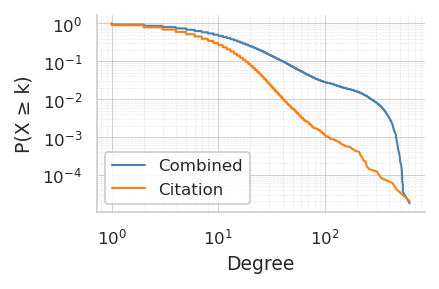

CCDF: in vs out-degree. Max in=616, out=128.


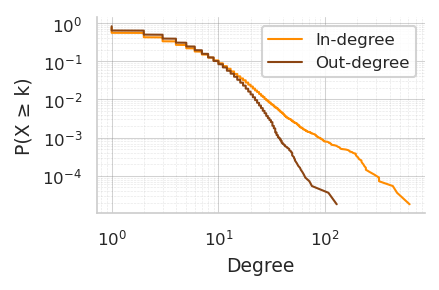

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

def _style_loglog_ax(ax):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


# ── Plot 1 – CCDF degree (undirected) ────────────────────────────────────────
print("CCDF degree (undirected).")

fig, ax = plt.subplots(figsize=(3, 2))

for arr, color, label in [
    (deg_bc,  COLORS['bc_uw'],  'Combined'),
    (deg_cit, COLORS['cit_ud'], 'Citation'),
]:
    x, y = ccdf(arr)
    ax.loglog(x, y, color=color, lw=1, label=label)

ax.set_xlabel('Degree')
ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=8, framealpha=0.85)
_style_loglog_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_undirected.png'),
            dpi=200, bbox_inches='tight')
plt.show()


# ── Plot 2 – CCDF in- vs out-degree (directed) ───────────────────────────────
print(f"CCDF: in vs out-degree. Max in={in_d.max()}, out={out_d.max()}.")

fig, ax = plt.subplots(figsize=(3, 2))

for arr, color, label in [
    (in_d,  COLORS['cit_d'],  'In-degree'),
    (out_d, 'saddlebrown',    'Out-degree'),
]:
    x, y = ccdf(arr)
    ax.loglog(x, y, color=color, lw=1, label=label)

ax.set_xlabel('Degree')
ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=8, framealpha=0.85)
_style_loglog_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_directed.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [8]:
print("Computing clustering coefficients ...")
clust_bc  = nx.clustering(lcc['bc_uw']);  clust_bc_v  = np.array(list(clust_bc.values()));  clust_bc_m  = nx.average_clustering(lcc['bc_uw'])
print(f"  Combined done — avg: {clust_bc_m:.4f}")
clust_cit = nx.clustering(lcc['cit_ud']); clust_cit_v = np.array(list(clust_cit.values())); clust_cit_m = nx.average_clustering(lcc['cit_ud'])
print(f"  Citation done — avg: {clust_cit_m:.4f}")
d_bc, d_cit = nx.density(lcc['bc_uw']), nx.density(lcc['cit_ud'])

df_cl = pd.DataFrame({
    'Metric': ['Avg clustering','Median','Std','C=0 (%)','C=1 (%)','Density'],
    'Combined': [clust_bc_m, np.median(clust_bc_v), np.std(clust_bc_v),
                 np.mean(clust_bc_v==0)*100, np.mean(clust_bc_v==1)*100, d_bc],
    'Citation': [clust_cit_m, np.median(clust_cit_v), np.std(clust_cit_v),
                 np.mean(clust_cit_v==0)*100, np.mean(clust_cit_v==1)*100, d_cit],
}).set_index('Metric')
print("\n"); print(df_cl.to_string(float_format=lambda x: f'{x:.6f}'))
print(f"\nDensity ratio: {d_bc/d_cit:.2f}x   Clustering ratio: {clust_bc_m/clust_cit_m:.2f}x")

Computing clustering coefficients ...
  Combined done — avg: 0.4366
  Citation done — avg: 0.3424


                Combined  Citation
Metric                            
Avg clustering  0.436614  0.342389
Median          0.418972  0.321429
Std             0.271862  0.284050
C=0 (%)        12.191989 21.379688
C=1 (%)         6.473370  6.756290
Density         0.000374  0.000173

Density ratio: 2.16x   Clustering ratio: 1.28x


Fig 1: CCDF clustering.


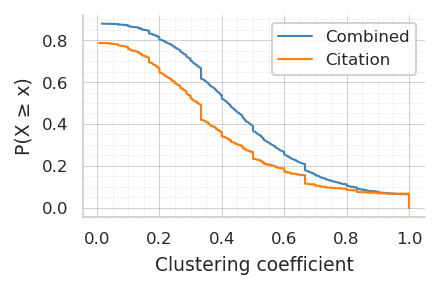

Fig 2: clustering violin + jitter.


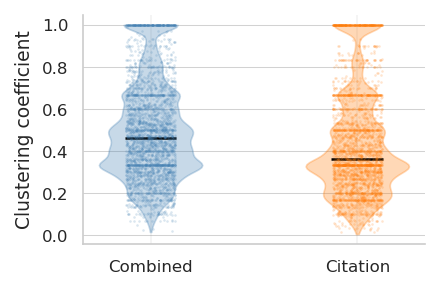

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

rng = np.random.default_rng(42)

def _jitter(v, x_center, width=0.12):
    return x_center + rng.uniform(-width, width, len(v))


# ── Plot 1 – CCDF clustering ──────────────────────────────────────────────────
print("Fig 1: CCDF clustering.")

fig, ax = plt.subplots(figsize=(3, 2))

for v, color, label in [
    (clust_bc_v,  COLORS['bc_uw'],  'Combined'),
    (clust_cit_v, COLORS['cit_ud'], 'Citation'),
]:
    p = np.sort(v[v > 0])[::-1]
    ax.plot(p, np.arange(1, len(p) + 1) / len(v), lw=1, color=color, label=label)

ax.set_xlabel('Clustering coefficient')
ax.set_ylabel('P(X ≥ x)')
ax.legend(fontsize=8, framealpha=0.85)
ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
ax.minorticks_on()
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'clustering_ccdf.png'), dpi=200, bbox_inches='tight')
plt.show()


# ── Plot 2 – Violin + jitter clustering ──────────────────────────────────────
print("Fig 2: clustering violin + jitter.")

datasets = [
    (clust_bc_v[clust_bc_v > 0],   COLORS['bc_uw'],  'Combined'),
    (clust_cit_v[clust_cit_v > 0], COLORS['cit_ud'], 'Citation'),
]

fig, ax = plt.subplots(figsize=(3, 2))

parts = ax.violinplot(
    [d[0] for d in datasets],
    positions=[1, 2],
    showmedians=True,
    showextrema=False,
    widths=0.5,
)

for body, (_, color, _) in zip(parts['bodies'], datasets):
    body.set_facecolor(color)
    body.set_alpha(0.3)
    body.set_edgecolor(color)
    body.set_linewidth(0.8)

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.2)

for i, (v, color, _) in enumerate(datasets, start=1):
    sample = v if len(v) <= 3000 else rng.choice(v, 3000, replace=False)
    ax.scatter(_jitter(sample, i), sample,
               color=color, alpha=0.2, s=1.5, lw=0, zorder=2)

ax.set_xticks([1, 2])
ax.set_xticklabels([d[2] for d in datasets])
ax.set_ylabel('Clustering coefficient')
ax.grid(True, which='major', ls='-', lw=0.5, alpha=0.35, color='gray', axis='y')
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'clustering_violin.png'), dpi=200, bbox_inches='tight')
plt.show()

In [10]:
CACHE_PATH = os.path.join(out_dir, 'path_stats_exact.csv')
CACHE_BETW = os.path.join(out_dir, 'betweenness_exact.csv')
CACHE_CLOS = os.path.join(out_dir, 'closeness_exact.csv')

# NetworKit uses OpenMP internally — set thread count once
nk.setNumberOfThreads(24)
print(f"NetworKit threads: {nk.getMaxNumberOfThreads()}")


def _nx_to_nk(G_nx):
    """Convert undirected NX graph to NK, return (G_nk, nx2nk, nk2nx)."""
    nodes = list(G_nx.nodes())
    nx2nk = {n: i for i, n in enumerate(nodes)}
    nk2nx = {i: n for n, i in nx2nk.items()}
    G_nk = nk.Graph(len(nodes), weighted=False, directed=False)
    for u, v in G_nx.edges():
        G_nk.addEdge(nx2nk[u], nx2nk[v])
    return G_nk, nx2nk, nk2nx


def _run_cent(G_nk, nk2nx, build_fn, label):
    """Run a NetworKit centrality algorithm. build_fn(G) -> algorithm."""
    t0 = time.time()
    algo = build_fn(G_nk)
    algo.run()
    s = algo.scores()
    print(f"  [{label}] done in {time.time()-t0:.1f}s ({len(s):,} nodes)")
    return {nk2nx[i]: s[i] for i in range(len(s))}


def _save_cent(d1, d2, path):
    pd.DataFrame(
        [{'node': n, 'graph': 'bc',  'value': v} for n, v in d1.items()]
      + [{'node': n, 'graph': 'cit', 'value': v} for n, v in d2.items()]
    ).to_csv(path, index=False)

def _load_cent(path):
    df = pd.read_csv(path)
    return {g: dict(zip(gr['node'], gr['value'])) for g, gr in df.groupby('graph')}


# ── Convert graphs (once) ────────────────────────────────────────────────────
print("Converting to NetworKit ...")
nk_bc,  _, nk2nx_bc  = _nx_to_nk(lcc['bc_uw'])
nk_cit, _, nk2nx_cit = _nx_to_nk(lcc['cit_ud'])
print(f"  Combined: {nk_bc.numberOfNodes():,} nodes, {nk_bc.numberOfEdges():,} edges")
print(f"  Citation: {nk_cit.numberOfNodes():,} nodes, {nk_cit.numberOfEdges():,} edges")


# ══════════════════════════════════════════════════════════════════════════════
# PATH ANALYSIS (exact BFS, vectorized inner loop)
# ══════════════════════════════════════════════════════════════════════════════

def path_exact(G_nk, label):
    """Exact avg path + diameter. Inner distance sum is vectorized via numpy."""
    n = G_nk.numberOfNodes()
    t0 = time.time()
    total_sum = 0
    total_cnt = 0
    global_max = 0

    print(f"\n  [{label}] Exact BFS from {n:,} nodes ...")
    for i, u in enumerate(G_nk.iterNodes()):
        bfs = nk.distance.BFS(G_nk, u)
        bfs.run()
        dists = np.array(bfs.getDistances())
        valid = (dists > 0) & (dists < 1e15)
        total_sum += dists[valid].sum()
        total_cnt += valid.sum()
        d_max = dists[valid].max() if valid.any() else 0
        if d_max > global_max:
            global_max = d_max

        if (i + 1) % 5000 == 0 or (i + 1) == n:
            print(f"    {i+1:,}/{n:,}  avg={total_sum/total_cnt:.4f}  "
                  f"max={int(global_max)}  {time.time()-t0:.0f}s")

    avg_path = total_sum / total_cnt if total_cnt else 0
    reach = 100.0 * total_cnt / (n * (n - 1)) if n > 1 else 0

    # Exact diameter via dedicated algorithm (faster than BFS max)
    t1 = time.time()
    print(f"  [{label}] Computing exact diameter ...")
    dm = nk.distance.Diameter(G_nk, algo=nk.distance.DiameterAlgo.EXACT)
    dm.run()
    diameter = int(dm.getDiameter()[0])
    print(f"    Diameter: {diameter} ({time.time()-t1:.1f}s)")

    print(f"  [{label}] Total: {time.time()-t0:.1f}s")
    return {'avg_path': avg_path, 'diameter': diameter,
            'reachability': reach, 'total_pairs': int(total_cnt)}


if os.path.exists(CACHE_PATH):
    print(f"\nPath cache: {CACHE_PATH}")
    dc = pd.read_csv(CACHE_PATH).set_index('graph')
    sp_bc  = dc.loc['bc'].to_dict()
    sp_cit = dc.loc['cit'].to_dict()
    print("  Loaded.")
else:
    print("\nComputing exact paths ...")
    sp_bc  = path_exact(nk_bc,  'Combined')
    sp_cit = path_exact(nk_cit, 'Citation')
    pd.DataFrame([
        {'graph': 'bc',  **sp_bc},
        {'graph': 'cit', **sp_cit},
    ]).to_csv(CACHE_PATH, index=False)
    print(f"  Saved to {CACHE_PATH}")

df_path = pd.DataFrame({
    'Metric':   ['Avg path', 'Diameter', 'Reachability (%)', 'Pairs'],
    'Combined': [sp_bc['avg_path'],  sp_bc['diameter'],
                 sp_bc['reachability'],  sp_bc['total_pairs']],
    'Citation': [sp_cit['avg_path'], sp_cit['diameter'],
                 sp_cit['reachability'], sp_cit['total_pairs']],
}).set_index('Metric')
print("\nPath analysis (exact)\n")
print(df_path.to_string())
red = (sp_cit['avg_path'] - sp_bc['avg_path']) / sp_cit['avg_path'] * 100
print(f"\nBC reduces avg path by {red:.1f}%")
print(f"Diameter: Combined={sp_bc['diameter']} | Citation={sp_cit['diameter']}")


# ══════════════════════════════════════════════════════════════════════════════
# CENTRALITY (all exact, OpenMP-parallelized)
# ══════════════════════════════════════════════════════════════════════════════

print("\n\nComputing degree (exact) ...")
deg_c_bc  = dict(lcc['bc_uw'].degree())
deg_c_cit = dict(lcc['cit_ud'].degree())
print(f"  Combined: {len(deg_c_bc):,} | Citation: {len(deg_c_cit):,}")

# Betweenness — normalized=True to match standard definition
if os.path.exists(CACHE_BETW):
    print(f"\nBetweenness cache: {CACHE_BETW}")
    c = _load_cent(CACHE_BETW)
    betw_bc = c['bc']; betw_cit = c['cit']
    print("  Loaded.")
else:
    print("\nComputing exact betweenness (OpenMP) ...")
    betw_bc  = _run_cent(nk_bc,  nk2nx_bc,
                         lambda G: nk.centrality.Betweenness(G, normalized=True),
                         'Combined')
    betw_cit = _run_cent(nk_cit, nk2nx_cit,
                         lambda G: nk.centrality.Betweenness(G, normalized=True),
                         'Citation')
    _save_cent(betw_bc, betw_cit, CACHE_BETW)
    print(f"  Saved to {CACHE_BETW}")

# Closeness — default normalized=True, consistent with NetworkX
if os.path.exists(CACHE_CLOS):
    print(f"\nCloseness cache: {CACHE_CLOS}")
    c = _load_cent(CACHE_CLOS)
    clos_bc = c['bc']; clos_cit = c['cit']
    print("  Loaded.")
else:
    print("\nComputing exact closeness (OpenMP) ...")
    clos_bc  = _run_cent(nk_bc,  nk2nx_bc,
                     lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD),
                     'Combined')
    clos_cit = _run_cent(nk_cit, nk2nx_cit,
                     lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD),
                     'Citation')
    _save_cent(clos_bc, clos_cit, CACHE_CLOS)
    print(f"  Saved to {CACHE_CLOS}")


# ── Summary ──────────────────────────────────────────────────────────────────
def _ds(d):
    v = np.array(list(d.values()))
    return {'Mean': np.mean(v), 'Std': np.std(v),
            'Max': np.max(v), 'P99': float(np.percentile(v, 99))}

df_cent = pd.DataFrame([
    {'Metric': l, **_ds(d)} for l, d in [
        ('Degree — Combined',  deg_c_bc),  ('Degree — Citation',  deg_c_cit),
        ('Betw. — Combined',   betw_bc),   ('Betw. — Citation',   betw_cit),
        ('Close. — Combined',  clos_bc),   ('Close. — Citation',  clos_cit)]
]).set_index('Metric')
print("\nCentrality (all exact)\n")
print(df_cent.to_string(float_format=lambda x: f'{x:.6f}'))

common = list(set(deg_c_bc) & set(deg_c_cit)
            & set(betw_bc) & set(betw_cit)
            & set(clos_bc) & set(clos_cit))
print(f"\nSpearman (Combined vs Citation) on {len(common):,} nodes:")
print(f"{'Metric':<18} {'ρ':>8} {'p':>12}")
print("-" * 42)
for l, a, b in [('Degree', deg_c_bc, deg_c_cit),
                ('Betweenness', betw_bc, betw_cit),
                ('Closeness', clos_bc, clos_cit)]:
    r, p = spearmanr([a[n] for n in common], [b[n] for n in common])
    print(f"  {l:<16} {r:>8.4f} {'< 0.001' if p < .001 else f'{p:.3f}':>12}")

print("\nTop-10 overlap:")
for l, a, b in [('Degree', deg_c_bc, deg_c_cit),
                ('Betweenness', betw_bc, betw_cit),
                ('Closeness', clos_bc, clos_cit)]:
    s1 = {n for n, _ in sorted(a.items(), key=lambda x: -x[1])[:10]}
    s2 = {n for n, _ in sorted(b.items(), key=lambda x: -x[1])[:10]}
    print(f"  {l:<18} {len(s1 & s2)}/10")

del nk_bc, nk_cit, nk2nx_bc, nk2nx_cit
gc.collect()
print("\nNetworKit objects released.")

NetworKit threads: 24
Converting to NetworKit ...
  Combined: 56,045 nodes, 586,866 edges
  Citation: 49,243 nodes, 209,599 edges

Path cache: ./output/path_stats_exact.csv
  Loaded.

Path analysis (exact)

                      Combined      Citation
Metric                                      
Avg path          8.349079e+00  1.181042e+01
Diameter          4.900000e+01  4.800000e+01
Reachability (%)  1.000000e+02  1.000000e+02
Pairs             3.140986e+09  2.424824e+09

BC reduces avg path by 29.3%
Diameter: Combined=49.0 | Citation=48.0


Computing degree (exact) ...
  Combined: 56,045 | Citation: 49,243

Betweenness cache: ./output/betweenness_exact.csv
  Loaded.

Closeness cache: ./output/closeness_exact.csv
  Loaded.

Centrality (all exact)

                       Mean       Std        Max        P99
Metric                                                     
Degree — Combined 20.942671 44.620978 621.000000 271.000000
Degree — Citation  8.512844 10.777638 621.000000  41.000000
B

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Closeness analysis + node role classification
# Roles based on percentile thresholds on degree × betweenness (Combined LCC)
# ══════════════════════════════════════════════════════════════════════════════

# ── Closeness summary ────────────────────────────────────────────────────────
print("Closeness centrality summary\n")
for label, d in [('Combined', clos_bc), ('Citation', clos_cit)]:
    v = np.array(list(d.values()))
    print(f"{label}:")
    print(f"  Mean: {v.mean():.6f}   Std: {v.std():.6f}   "
          f"Max: {v.max():.6f}   P99: {np.percentile(v,99):.6f}")
    print(f"  Nodes with closeness > mean+2σ: {(v > v.mean() + 2*v.std()).sum():,}\n")

common_clos = list(set(clos_bc) & set(clos_cit))
rho_clos, pval_clos = spearmanr(
    [clos_bc[n] for n in common_clos],
    [clos_cit[n] for n in common_clos])
print(f"Spearman closeness Combined vs Citation: ρ={rho_clos:.4f}  "
      f"p={'< 0.001' if pval_clos < .001 else f'{pval_clos:.3f}'}")

t10_bc  = sorted(clos_bc.items(),  key=lambda x: -x[1])[:10]
t10_cit = sorted(clos_cit.items(), key=lambda x: -x[1])[:10]
overlap = {n for n,_ in t10_bc} & {n for n,_ in t10_cit}
print(f"Top-10 overlap: {len(overlap)}/10\n")

# ── Node role classification (on Combined LCC) ──────────────────────────────
# Based on degree × betweenness percentiles
common_role = list(set(deg_c_bc) & set(betw_bc) & set(clos_bc))
deg_vals  = np.array([deg_c_bc[n]  for n in common_role])
betw_vals = np.array([betw_bc[n]   for n in common_role])

p50_d, p95_d = np.percentile(deg_vals,  [50, 95])
p50_b, p95_b = np.percentile(betw_vals, [50, 95])

roles = {}
for j, n in enumerate(common_role):
    d, b = deg_vals[j], betw_vals[j]
    if d > p95_d and b > p95_b:
        roles[n] = 'Global Hub'
    elif d > p95_d and b < p50_b:
        roles[n] = 'Local Hub'
    elif d < p50_d and b > p95_b:
        roles[n] = 'Strategic Bridge'
    elif p50_d <= d <= p95_d and p50_b <= b <= p95_b:
        roles[n] = 'Intermediate'
    else:
        roles[n] = 'Uncategorized'

role_counts = Counter(roles.values())
print("Node role classification (Combined LCC):")
print(f"  {'Role':<20} {'Count':>8} {'%':>8}")
print("-" * 40)
for role in ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate', 'Uncategorized']:
    c = role_counts.get(role, 0)
    print(f"  {role:<20} {c:>8,} {c/len(common_role)*100:>7.1f}%")

# ── Closeness by role ────────────────────────────────────────────────────────
print("\nCloseness by node role (Combined graph):")
print(f"  {'Role':<20} {'Count':>7} {'Mean':>10} {'Median':>10} {'Max':>10}")
print("-" * 62)
for role in ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate', 'Uncategorized']:
    nodes_in_role = [n for n, r in roles.items() if r == role and n in clos_bc]
    if not nodes_in_role:
        continue
    cv = np.array([clos_bc[n] for n in nodes_in_role])
    print(f"  {role:<20} {len(cv):>7,} {cv.mean():>10.6f} {np.median(cv):>10.6f} {cv.max():>10.6f}")

# ── Top-10 closeness with role annotation ────────────────────────────────────
print("\nTop-10 nodes by closeness (Combined):")
print(f"  {'Rank':<5} {'Closeness':>10} {'Degree':>8} {'Betw.':>10} {'Role':<20}")
print("-" * 58)
for rank, (n, c) in enumerate(t10_bc, 1):
    d = deg_c_bc.get(n, 0)
    b = betw_bc.get(n, 0)
    r = roles.get(n, '—')
    print(f"  {rank:<5} {c:>10.6f} {d:>8} {b:>10.6f} {r:<20}")

Closeness centrality summary

Combined:
  Mean: 0.122537   Std: 0.016407   Max: 0.171193   P99: 0.153023
  Nodes with closeness > mean+2σ: 347

Citation:
  Mean: 0.087034   Std: 0.013119   Max: 0.127029   P99: 0.110732
  Nodes with closeness > mean+2σ: 180

Spearman closeness Combined vs Citation: ρ=0.6199  p=< 0.001
Top-10 overlap: 0/10

Node role classification (Combined LCC):
  Role                    Count        %
----------------------------------------
  Global Hub                330     0.6%
  Local Hub                 790     1.4%
  Strategic Bridge          369     0.7%
  Intermediate           14,692    26.2%
  Uncategorized          39,864    71.1%

Closeness by node role (Combined graph):
  Role                   Count       Mean     Median        Max
--------------------------------------------------------------
  Global Hub               330   0.150989   0.152192   0.168222
  Local Hub                790   0.137738   0.138877   0.159694
  Strategic Bridge         369   0

Fig: centrality CCDF + cross-graph scatter.


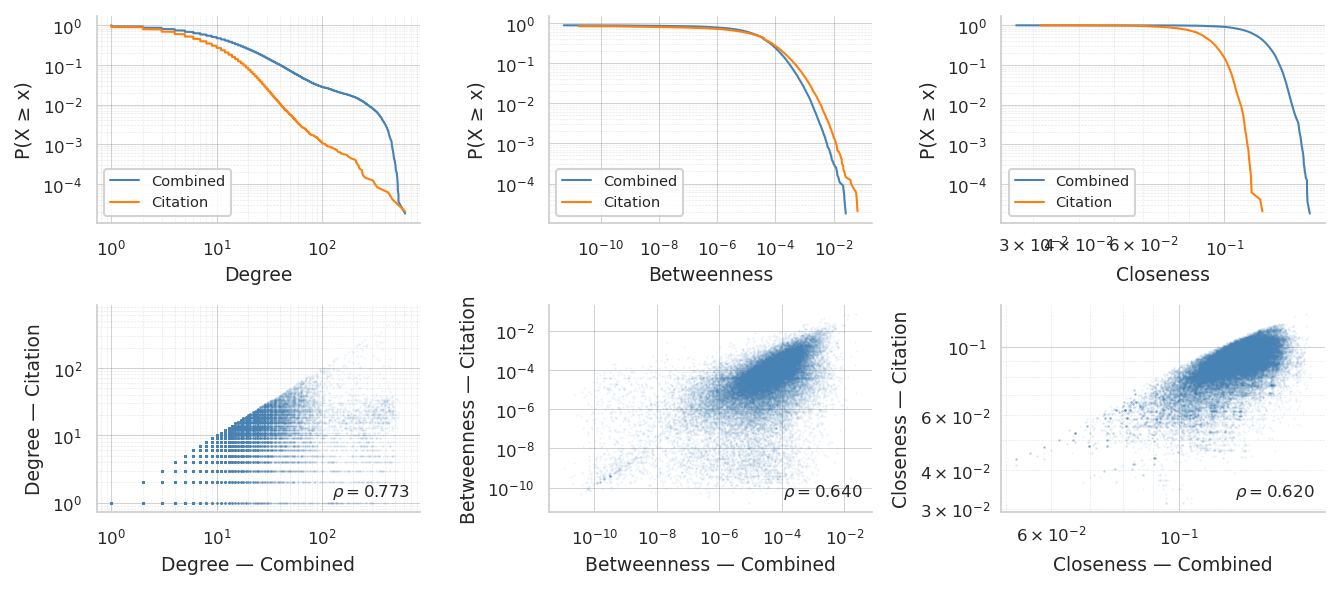

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from scipy.stats import spearmanr

plt.rcParams.update({
    'font.size': 9, 'axes.labelsize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

def _style_loglog_ax(ax):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


print("Fig: centrality CCDF + cross-graph scatter.")

centralities = [
    ('Degree',      deg_c_bc,  deg_c_cit),
    ('Betweenness', betw_bc,   betw_cit),
    ('Closeness',   clos_bc,   clos_cit),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 4))

for j, (lbl, d_bc, d_cit) in enumerate(centralities):

    # ── riga 0: CCDF ──────────────────────────────────────────────────────
    ax = axes[0, j]
    for d, color, label in [
        (d_bc,  COLORS['bc_uw'],  'Combined'),
        (d_cit, COLORS['cit_ud'], 'Citation'),
    ]:
        v = np.array(list(d.values()))
        s = np.sort(v[v > 0])[::-1]
        ax.loglog(s, np.arange(1, len(s) + 1) / len(v),
                  color=color, lw=1, label=label)
    ax.set_xlabel(lbl)
    ax.set_ylabel('P(X ≥ x)')
    ax.legend(fontsize=7, framealpha=0.85)
    _style_loglog_ax(ax)

    # ── riga 1: scatter cross-graph ───────────────────────────────────────
    ax = axes[1, j]
    cn = list(set(d_bc) & set(d_cit))
    x  = np.array([d_bc[n]  for n in cn])
    y  = np.array([d_cit[n] for n in cn])
    ax.scatter(x, y, color=COLORS['bc_uw'], alpha=0.1, s=1, lw=0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'{lbl} — Combined')
    ax.set_ylabel(f'{lbl} — Citation')
    rho, _ = spearmanr(x, y)
    ax.text(0.97, 0.05, fr'$\rho={rho:.3f}$',
            transform=ax.transAxes, fontsize=8,
            ha='right', va='bottom')
    _style_loglog_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'centrality_analysis.png'),
            dpi=200, bbox_inches='tight')
plt.show()

Combined  LCC: N=56,045  M=586,866  ⟨k⟩=20.94
Citation  LCC: N=49,243  M=209,599  ⟨k⟩=8.51

Generating null models ...
  ER edges:  Combined=586,866 (target 586,866)  Citation=209,599 (target 209,599)
  BA m:      Combined m=10 → 560,350 edges  Citation m=4 → 196,956 edges

── Theoretical predictions ──

  Combined:
    ER:  C=0.000374  d=3.59  σ_k=4.58  k_max≈48
    BA:  C=0.005333  d=4.57  k_max≈2367

  Citation:
    ER:  C=0.000173  d=5.05  σ_k=2.92  k_max≈26
    BA:  C=0.002371  d=4.54  k_max≈888

Computing empirical null-model metrics (500-node BFS sample) ...
  Done in 64.6s

════════════════════════════════════════════════════════════════════════════════
Combined LCC vs null models
════════════════════════════════════════════════════════════════════════════════
           N       M    LCC    ⟨k⟩   C (emp) C (theory)  d (emp) d (theory)  k_max (emp) k_max (theory)  σ_k (emp)       σ
Graph                                                                                             

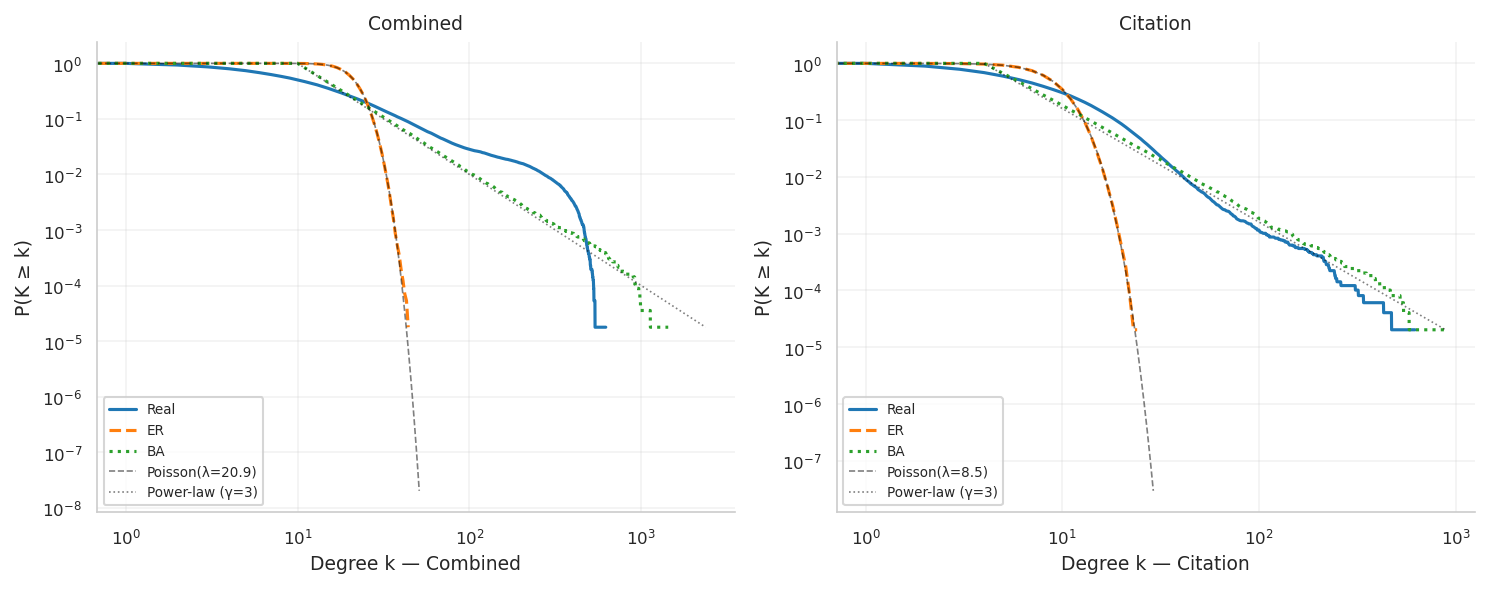

── Fig 2: Clustering coefficient comparison ──


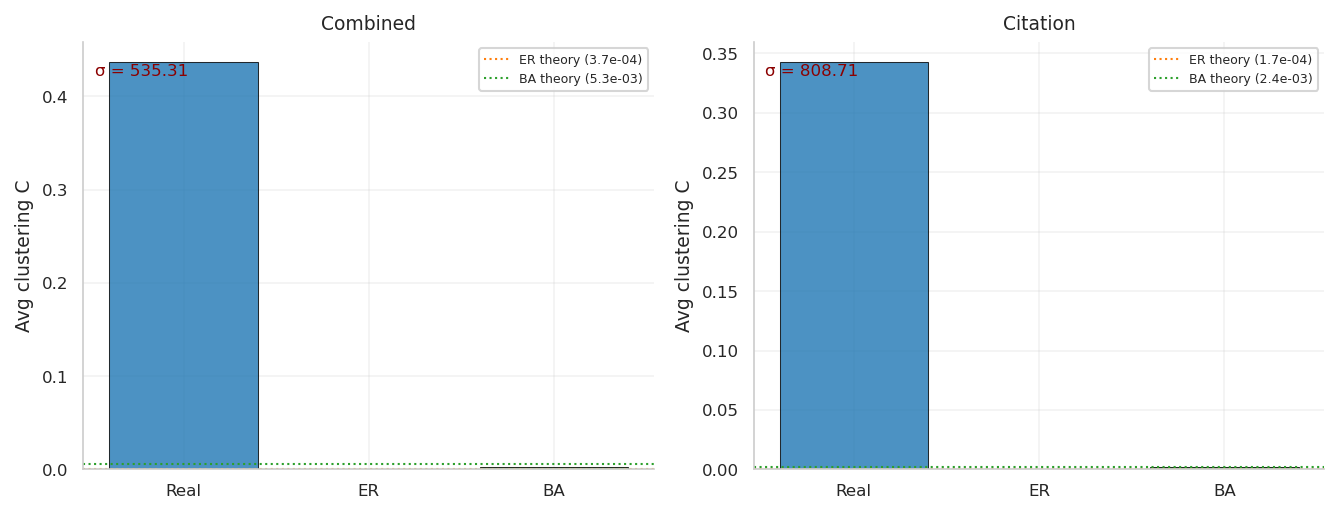

── Fig 3: Average path length comparison ──


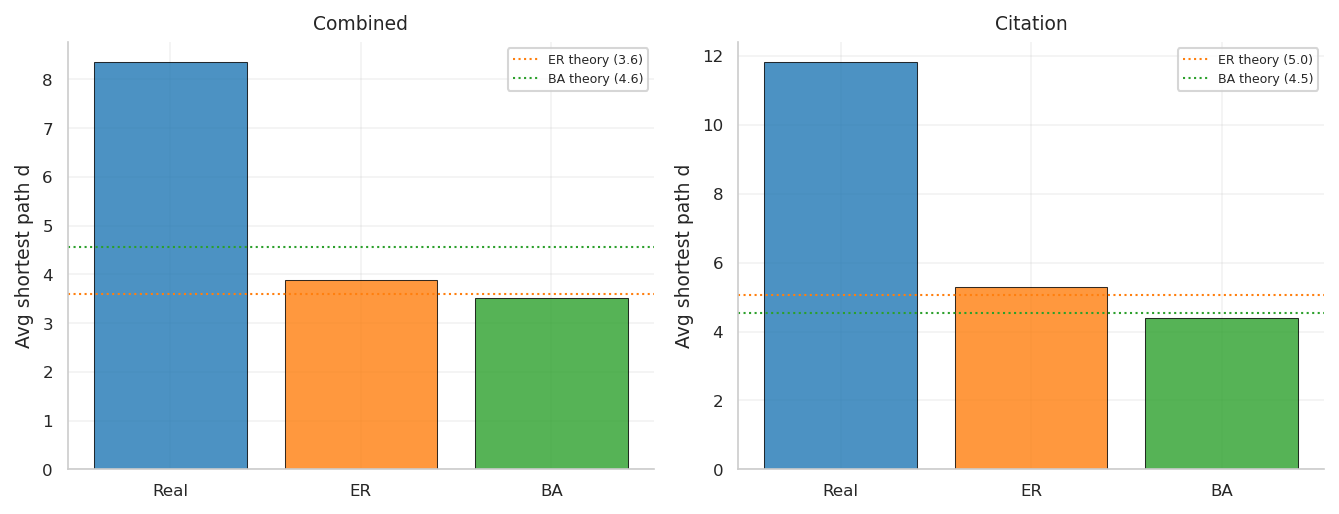

── Fig 4: Degree PDF — low-k regime (linear) ──


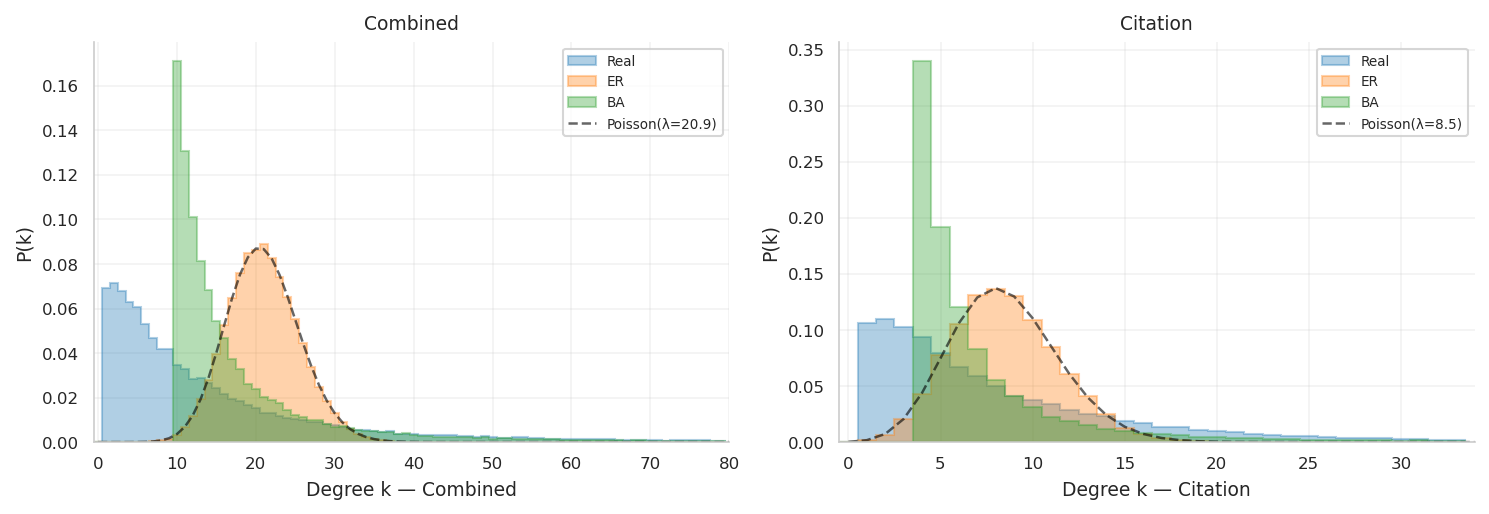


Null models released.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Null-model comparison: ER & BA vs real graphs
# Includes theoretical predictions from Erdős-Rényi and Barabási-Albert theory
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import poisson
from math import log, sqrt

# ── 1. Real-graph parameters ─────────────────────────────────────────────────
N_b, M_b = lcc['bc_uw'].number_of_nodes(), lcc['bc_uw'].number_of_edges()
N_c, M_c = lcc['cit_ud'].number_of_nodes(), lcc['cit_ud'].number_of_edges()
k_avg_b, k_avg_c = 2 * M_b / N_b, 2 * M_c / N_c

print(f"Combined  LCC: N={N_b:,}  M={M_b:,}  ⟨k⟩={k_avg_b:.2f}")
print(f"Citation  LCC: N={N_c:,}  M={M_c:,}  ⟨k⟩={k_avg_c:.2f}")

# ── 2. Generate null models ──────────────────────────────────────────────────
print("\nGenerating null models ...")
er_b = nx.gnm_random_graph(N_b, M_b, seed=42)
er_c = nx.gnm_random_graph(N_c, M_c, seed=42)

# BA: m = round(⟨k⟩/2), since BA produces ⟨k⟩ ≈ 2m
m_b = max(1, round(M_b / N_b))       # ≈ ⟨k⟩/2
m_c = max(1, round(M_c / N_c))
ba_b = nx.barabasi_albert_graph(N_b, m_b, seed=42)
ba_c = nx.barabasi_albert_graph(N_c, m_c, seed=42)

print(f"  ER edges:  Combined={er_b.number_of_edges():,} (target {M_b:,})  "
      f"Citation={er_c.number_of_edges():,} (target {M_c:,})")
print(f"  BA m:      Combined m={m_b} → {ba_b.number_of_edges():,} edges  "
      f"Citation m={m_c} → {ba_c.number_of_edges():,} edges")

# ── 3. Theoretical predictions ───────────────────────────────────────────────
# ER theory (slides Ch.3):
#   C_ER = ⟨k⟩ / (N-1) = p
#   d_ER = ln(N) / ln(⟨k⟩)
#   σ_k  = √⟨k⟩  (Poisson std dev)
# BA theory (slides Ch.5, γ=3):
#   ⟨k⟩  = 2m
#   C_BA = (m/4) · (ln N)² / N
#   d_BA = ln(N) / ln(ln(N))
#   k_max = m · √N  (since γ=3 → k_max = k_min · N^{1/(γ-1)})

def theoretical_er(N, M):
    k = 2 * M / N
    p = k / (N - 1)
    return {
        '⟨k⟩': round(k, 2),
        'p': f"{p:.2e}",
        'C (theory)': round(p, 6),
        'd (theory)': round(log(N) / log(k), 2) if k > 1 else float('inf'),
        'σ_k': round(sqrt(k), 2),
        'k_max (theory)': round(k + 6 * sqrt(k)),   # ≈ ⟨k⟩ + 6σ for Poisson
    }

def theoretical_ba(N, m):
    k = 2 * m
    gamma = 3
    return {
        '⟨k⟩': k,
        'm': m,
        'γ': gamma,
        'C (theory)': round((m / 4) * (log(N) ** 2) / N, 6),
        'd (theory)': round(log(N) / log(log(N)), 2),
        'k_max (theory)': round(m * sqrt(N)),   # k_min · N^{1/(γ-1)}
    }

th_er_b, th_er_c = theoretical_er(N_b, M_b), theoretical_er(N_c, M_c)
th_ba_b, th_ba_c = theoretical_ba(N_b, m_b), theoretical_ba(N_c, m_c)

print("\n── Theoretical predictions ──")
for label, th_er, th_ba in [("Combined", th_er_b, th_ba_b), ("Citation", th_er_c, th_ba_c)]:
    print(f"\n  {label}:")
    print(f"    ER:  C={th_er['C (theory)']:.6f}  d={th_er['d (theory)']:.2f}  "
          f"σ_k={th_er['σ_k']}  k_max≈{th_er['k_max (theory)']}")
    print(f"    BA:  C={th_ba['C (theory)']:.6f}  d={th_ba['d (theory)']:.2f}  "
          f"k_max≈{th_ba['k_max (theory)']}")

# ── 4. Empirical stats on null models ────────────────────────────────────────
def nm_stats(G, label, n_samp=500):
    """Compute clustering + sampled path stats on the LCC of G."""
    if not nx.is_connected(G):
        L = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    else:
        L = G
    cl = nx.average_clustering(L)
    nodes = list(L.nodes())
    rng = np.random.default_rng(42)
    samp = rng.choice(nodes, size=min(n_samp, len(nodes)), replace=False)
    ds = []
    for n in samp:
        lengths = nx.single_source_shortest_path_length(L, n)
        ds.extend(d for d in lengths.values() if d > 0)
    degs = np.array([d for _, d in G.degree()])
    return {
        'Graph': label,
        'N': G.number_of_nodes(),
        'M': G.number_of_edges(),
        'LCC': L.number_of_nodes(),
        '⟨k⟩': round(2 * L.number_of_edges() / L.number_of_nodes(), 2),
        'C (emp)': round(cl, 6),
        'd (emp)': round(float(np.mean(ds)), 2),
        'Diam (est)': int(np.max(ds)),
        'k_max (emp)': int(degs.max()),
        'σ_k (emp)': round(float(degs.std()), 2),
    }

print("\nComputing empirical null-model metrics (500-node BFS sample) ...")
t0 = time.time()
stats_er_b = nm_stats(er_b, 'ER')
stats_er_c = nm_stats(er_c, 'ER')
stats_ba_b = nm_stats(ba_b, 'BA')
stats_ba_c = nm_stats(ba_c, 'BA')
print(f"  Done in {time.time()-t0:.1f}s")

# Real-graph row: reuse exact values already computed
def real_row(G, label, sp_dict, clust_avg):
    degs = np.array([d for _, d in G.degree()])
    return {
        'Graph': label,
        'N': G.number_of_nodes(),
        'M': G.number_of_edges(),
        'LCC': G.number_of_nodes(),   # already is the LCC
        '⟨k⟩': round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
        'C (emp)': round(clust_avg, 6),
        'd (emp)': round(sp_dict['avg_path'], 2),
        'Diam (est)': int(sp_dict['diameter']),
        'k_max (emp)': int(degs.max()),
        'σ_k (emp)': round(float(degs.std()), 2),
    }

r_real_b = real_row(lcc['bc_uw'], 'Real', sp_bc, clust_bc_m)
r_real_c = real_row(lcc['cit_ud'], 'Real', sp_cit, clust_cit_m)

# ── 5. Build comparison tables ───────────────────────────────────────────────
def build_table(r_real, s_er, s_ba, th_er, th_ba):
    """Merge empirical + theoretical into one table."""
    rows = []
    for s, th, model in [(s_er, th_er, 'ER'), (s_ba, th_ba, 'BA')]:
        row = dict(s)
        row['C (theory)'] = th['C (theory)']
        row['d (theory)'] = th['d (theory)']
        row['k_max (theory)'] = th.get('k_max (theory)', '—')
        rows.append(row)
    # Real row has no theory
    r = dict(r_real)
    r['C (theory)'] = '—'
    r['d (theory)'] = '—'
    r['k_max (theory)'] = '—'
    return [r] + rows

tab_b = build_table(r_real_b, stats_er_b, stats_ba_b, th_er_b, th_ba_b)
tab_c = build_table(r_real_c, stats_er_c, stats_ba_c, th_er_c, th_ba_c)

# Small-world coefficient σ (Humphries & Gurney 2008): σ = (C_real/C_ER) / (L_real/L_ER)
for tab in [tab_b, tab_c]:
    Ce, Le = tab[1]['C (emp)'], tab[1]['d (emp)']
    Cr, Lr = tab[0]['C (emp)'], tab[0]['d (emp)']
    sigma = round((Cr / Ce) / (Lr / Le), 2) if Ce > 0 and Le > 0 else '—'
    tab[0]['σ'] = sigma
    tab[1]['σ'] = '—'
    tab[2]['σ'] = '—'

cols_display = ['Graph', 'N', 'M', 'LCC', '⟨k⟩',
                'C (emp)', 'C (theory)', 'd (emp)', 'd (theory)',
                'k_max (emp)', 'k_max (theory)', 'σ_k (emp)', 'σ']

for title, tab in [("Combined LCC vs null models", tab_b),
                    ("Citation LCC vs null models", tab_c)]:
    print(f"\n{'═'*80}\n{title}\n{'═'*80}")
    df = pd.DataFrame(tab)[cols_display].set_index('Graph')
    print(df.to_string())

# ── 6. Degree CCDF with theoretical overlays ─────────────────────────────────
def degree_ccdf(G):
    """Proper CCDF: for each k, compute P(K >= k)."""
    degs = np.array([d for _, d in G.degree()])
    vals = np.arange(0, degs.max() + 1)
    ccdf = np.array([np.mean(degs >= k) for k in vals])
    mask = ccdf > 0
    return vals[mask], ccdf[mask]

def poisson_ccdf(k_avg, k_max):
    """Theoretical Poisson CCDF."""
    k = np.arange(0, k_max + 1)
    ccdf = 1 - poisson.cdf(k - 1, k_avg)   # P(K >= k) = 1 - P(K <= k-1)
    mask = ccdf > 1e-8
    return k[mask], ccdf[mask]

def powerlaw_ccdf(gamma, k_min, k_max):
    """Theoretical power-law CCDF: P(K >= k) ~ (k/k_min)^{-(gamma-1)}."""
    k = np.arange(k_min, k_max + 1, dtype=float)
    ccdf = (k / k_min) ** (-(gamma - 1))
    return k, ccdf

print("\n── Fig 1: Degree CCDF vs null models + theoretical curves ──")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
datasets = [
    (lcc['bc_uw'], er_b, ba_b, k_avg_b, m_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, k_avg_c, m_c, 'Citation'),
]
for ax, (real, er, ba, kavg, m, gname) in zip(axes, datasets):
    # Empirical CCDFs
    for G, c, lab, ls in [(real, 'tab:blue', 'Real', '-'),
                          (er, 'tab:orange', 'ER', '--'),
                          (ba, 'tab:green', 'BA', ':')]:
        x, y = degree_ccdf(G)
        ax.loglog(x, y, color=c, label=lab, lw=1.5, ls=ls)
    # Theoretical Poisson CCDF
    kp, yp = poisson_ccdf(kavg, int(kavg + 8 * sqrt(kavg)))
    ax.loglog(kp, yp, 'k--', lw=0.8, alpha=0.5, label=f'Poisson(λ={kavg:.1f})')
    # Theoretical power-law CCDF (γ=3)
    kpl, ypl = powerlaw_ccdf(3.0, m, int(m * sqrt(real.number_of_nodes())))
    ax.loglog(kpl, ypl, 'k:', lw=0.8, alpha=0.5, label='Power-law (γ=3)')
    ax.set_xlabel(f'Degree k — {gname}')
    ax.set_ylabel('P(K ≥ k)')
    ax.legend(fontsize=6.5, loc='lower left')
    ax.set_title(gname, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_vs_null.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 7. Clustering comparison (bar + theoretical markers) ─────────────────────
print("── Fig 2: Clustering coefficient comparison ──")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
NC = {'Real': 'tab:blue', 'ER': 'tab:orange', 'BA': 'tab:green'}
for ax, (tab, th_er, th_ba, gname) in zip(axes, [
    (tab_b, th_er_b, th_ba_b, 'Combined'),
    (tab_c, th_er_c, th_ba_c, 'Citation'),
]):
    labels = [r['Graph'] for r in tab]
    vals   = [r['C (emp)'] for r in tab]
    colors = [NC[l] for l in labels]
    bars = ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='k', lw=0.5)
    # Theoretical values as horizontal markers
    ax.axhline(th_er['C (theory)'], color='tab:orange', ls=':', lw=1,
               label=f"ER theory ({th_er['C (theory)']:.1e})")
    ax.axhline(th_ba['C (theory)'], color='tab:green', ls=':', lw=1,
               label=f"BA theory ({th_ba['C (theory)']:.1e})")
    ax.set_ylabel('Avg clustering C')
    ax.set_title(gname, fontsize=9)
    ax.text(0.02, 0.95, f"σ = {tab[0]['σ']}",
            transform=ax.transAxes, fontsize=8, color='darkred', va='top')
    ax.legend(fontsize=6, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_clustering.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 8. Avg path length comparison ────────────────────────────────────────────
print("── Fig 3: Average path length comparison ──")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (tab, th_er, th_ba, gname) in zip(axes, [
    (tab_b, th_er_b, th_ba_b, 'Combined'),
    (tab_c, th_er_c, th_ba_c, 'Citation'),
]):
    labels = [r['Graph'] for r in tab]
    vals   = [r['d (emp)'] for r in tab]
    colors = [NC[l] for l in labels]
    ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='k', lw=0.5)
    ax.axhline(th_er['d (theory)'], color='tab:orange', ls=':', lw=1,
               label=f"ER theory ({th_er['d (theory)']:.1f})")
    ax.axhline(th_ba['d (theory)'], color='tab:green', ls=':', lw=1,
               label=f"BA theory ({th_ba['d (theory)']:.1f})")
    ax.set_ylabel('Avg shortest path d')
    ax.set_title(gname, fontsize=9)
    ax.legend(fontsize=6, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_path.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 9. Degree PDF comparison (linear scale, low-k regime) ────────────────────
print("── Fig 4: Degree PDF — low-k regime (linear) ──")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (real, er, ba, kavg, gname) in zip(axes, [
    (lcc['bc_uw'], er_b, ba_b, k_avg_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, k_avg_c, 'Citation'),
]):
    k_cut = int(min(4 * kavg, 80))
    for G, c, lab, ls in [(real, 'tab:blue', 'Real', '-'),
                          (er, 'tab:orange', 'ER', '--'),
                          (ba, 'tab:green', 'BA', ':')]:
        degs = np.array([d for _, d in G.degree()])
        bins = np.arange(0, k_cut + 1) - 0.5
        ax.hist(degs, bins=bins, density=True, alpha=0.35, color=c,
                label=lab, edgecolor=c, lw=0.7, histtype='stepfilled')
    # Theoretical Poisson overlay
    k_th = np.arange(0, k_cut + 1)
    ax.plot(k_th, poisson.pmf(k_th, kavg), 'k--', lw=1.2, alpha=0.6,
            label=f'Poisson(λ={kavg:.1f})')
    ax.set_xlabel(f'Degree k — {gname}')
    ax.set_ylabel('P(k)')
    ax.set_xlim(-0.5, k_cut)
    ax.legend(fontsize=6.5)
    ax.set_title(gname, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_pdf_linear.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── Cleanup ──────────────────────────────────────────────────────────────────
del er_b, er_c, ba_b, ba_c
gc.collect()
print("\nNull models released.")

Combined  LCC: N=56,045  M=586,866  ⟨k⟩=20.94
Citation  LCC: N=49,243  M=209,599  ⟨k⟩=8.51

Fitted power-law exponents:
  Combined: γ=2.39, k_min=25, tail nodes=11,121
  Citation: γ=3.54, k_min=17, tail nodes=6,045

Generating null models ...
  ER:  Combined=586,866 (=586,866)  Citation=209,599 (=209,599)
  BA:  Combined m=10 → 560,350 edges  Citation m=4 → 196,956 edges
  CM:  Combined=583,523 (target 586,866, lost 3,343)  Citation=209,486 (target 209,599, lost 113)

── Theoretical predictions ──

  Combined:
    ER:    C=0.000374  d=3.59  k_max≈48
    BA:    C=0.005333  d=4.57  k_max≈2367  (γ=3)
    CM:    C=0.011270  ⟨k_nn⟩=116.01
    Fit:   γ=2.39  k_max≈65186  d≈7.26

  Citation:
    ER:    C=0.000173  d=5.05  k_max≈26
    BA:    C=0.002371  d=4.54  k_max≈888  (γ=3)
    CM:    C=0.001068  ⟨k_nn⟩=22.16
    Fit:   γ=3.54  k_max≈1196  d≈~ln N

Computing empirical null-model metrics (500-node BFS sample) ...
  Done in 118.7s

═══════════════════════════════════════════════════════════

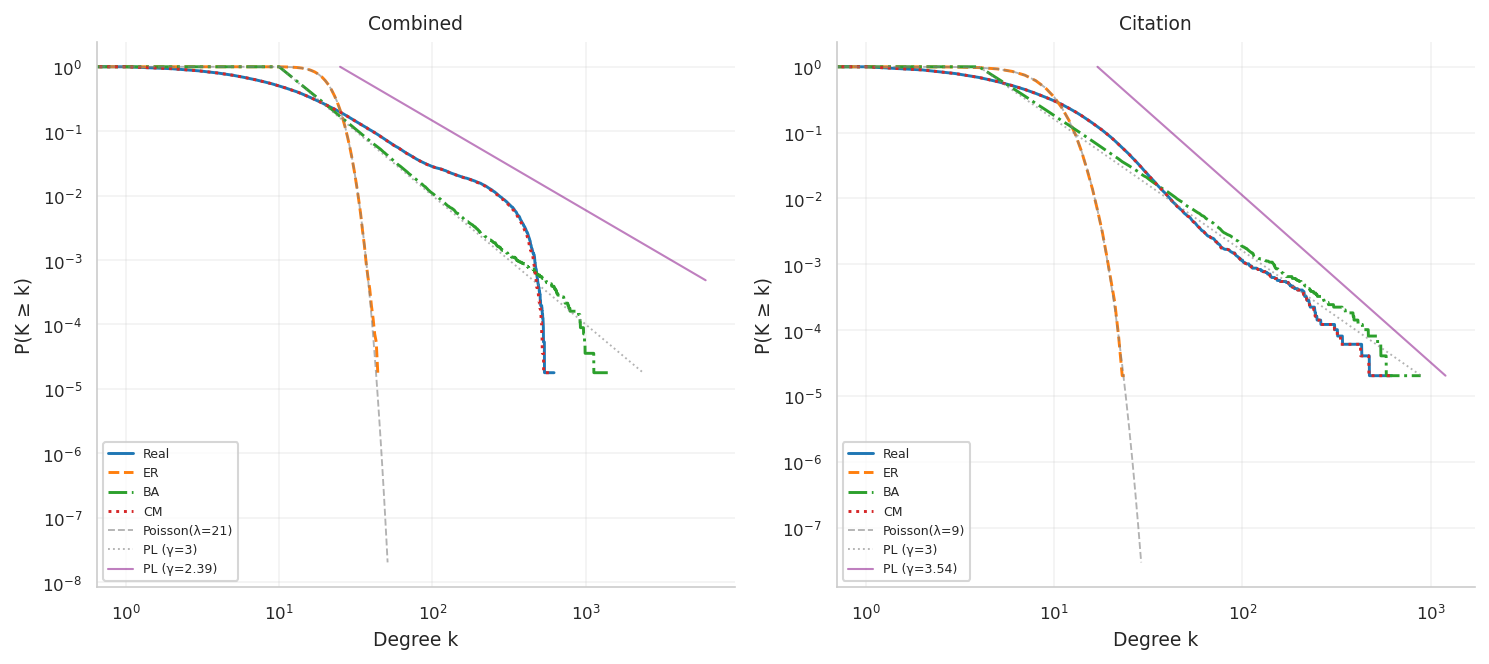

── Fig 2: Clustering coefficient comparison ──


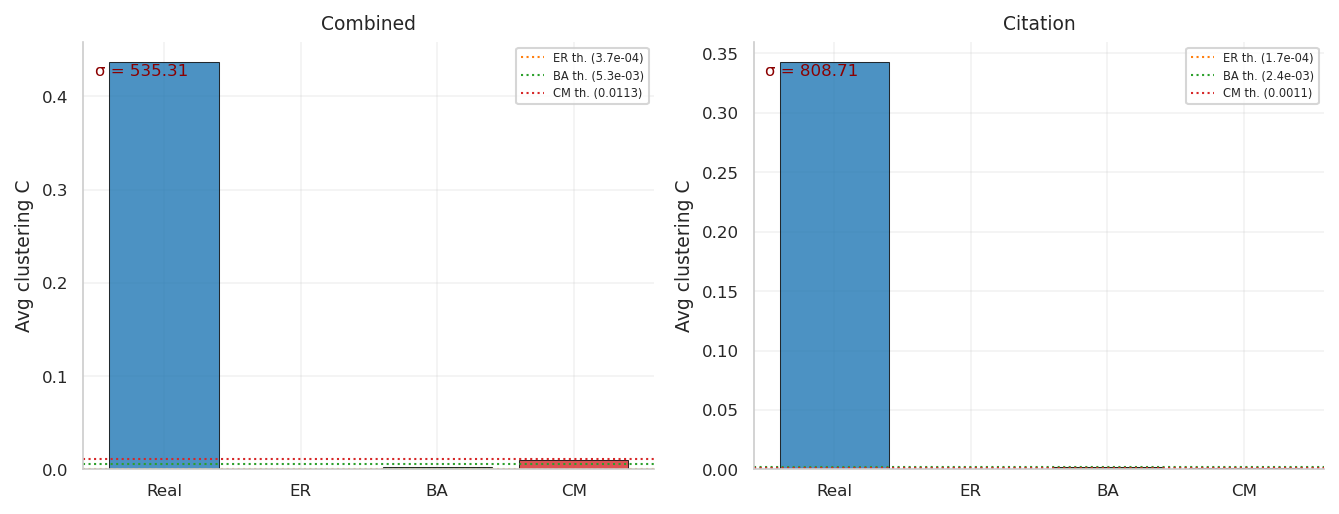

── Fig 3: Average path length comparison ──


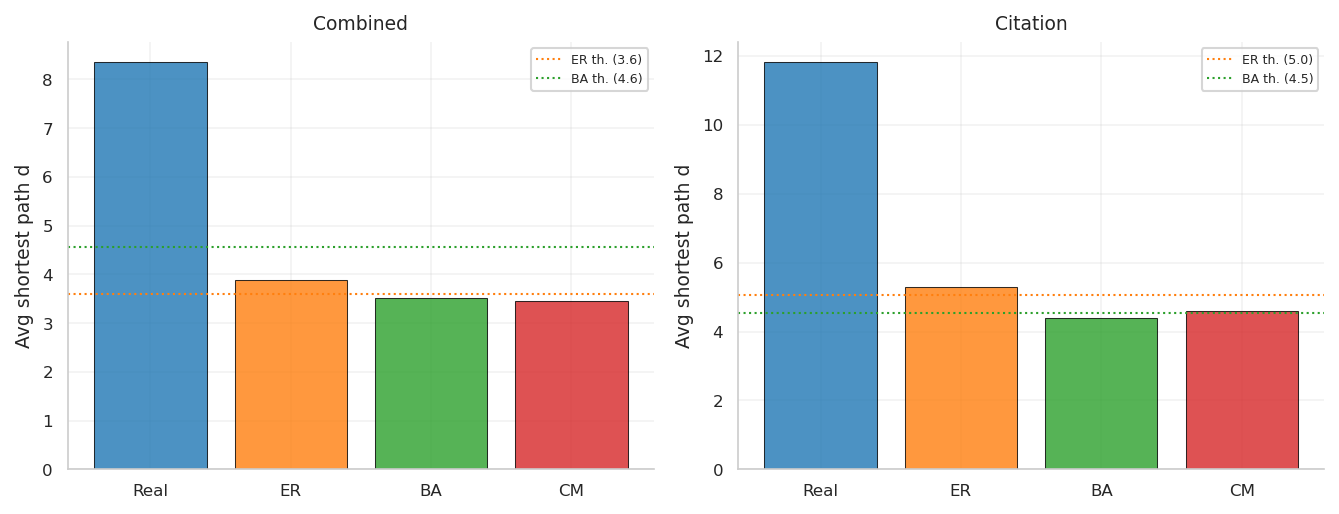

── Fig 4: Degree PDF — low-k regime (linear) ──


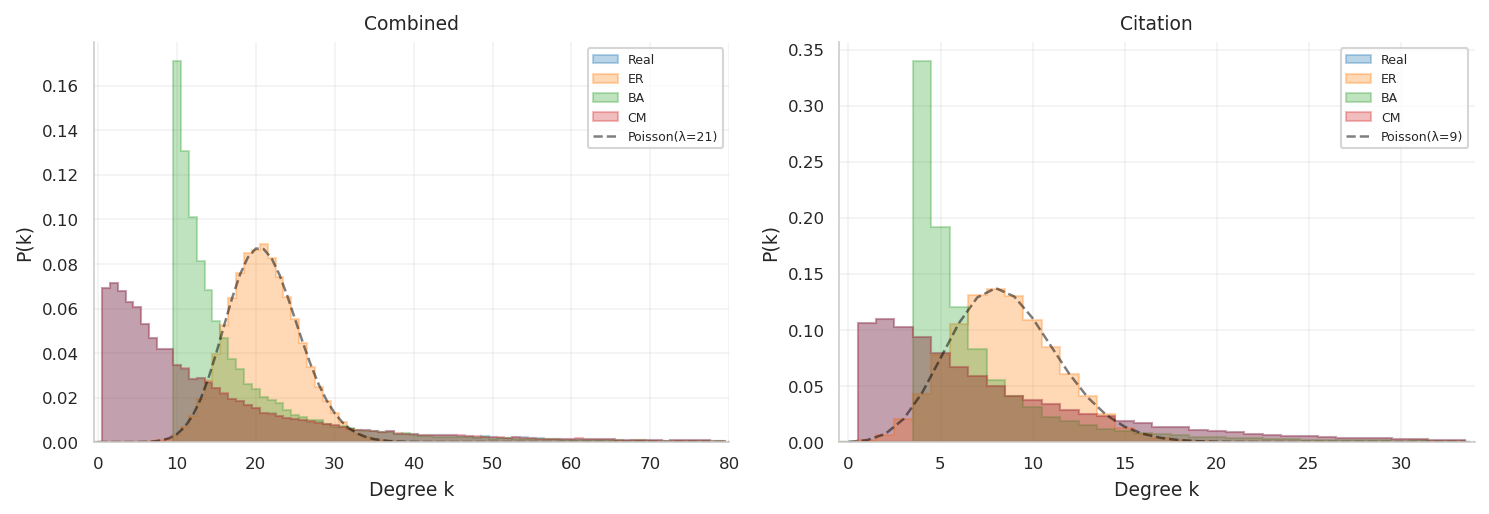


Null models released.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Null-model comparison: ER, BA & Configuration Model vs real graphs
# Theoretical predictions from Erdős-Rényi (Ch.3), Barabási-Albert (Ch.5),
# Configuration Model (Ch.3 advanced), and fitted power-law exponent γ.
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import poisson
from math import log, sqrt, lgamma as log_gamma
from collections import Counter

# ── 1. Real-graph parameters ─────────────────────────────────────────────────
N_b, M_b = lcc['bc_uw'].number_of_nodes(), lcc['bc_uw'].number_of_edges()
N_c, M_c = lcc['cit_ud'].number_of_nodes(), lcc['cit_ud'].number_of_edges()
k_avg_b, k_avg_c = 2 * M_b / N_b, 2 * M_c / N_c
deg_seq_b = [d for _, d in lcc['bc_uw'].degree()]
deg_seq_c = [d for _, d in lcc['cit_ud'].degree()]

print(f"Combined  LCC: N={N_b:,}  M={M_b:,}  ⟨k⟩={k_avg_b:.2f}")
print(f"Citation  LCC: N={N_c:,}  M={M_c:,}  ⟨k⟩={k_avg_c:.2f}")

# ── 2. Fit power-law exponent γ (MLE, Clauset et al. 2009) ───────────────────
def fit_powerlaw_gamma(degrees, k_min=None):
    """MLE estimate of γ for P(k) ~ k^{-γ}, discrete case.
    Uses the Hill estimator: γ = 1 + n / Σ ln(k_i / (k_min - 0.5))
    Returns γ, k_min, n_tail (number of points used)."""
    d = np.array(degrees)
    d = d[d > 0]  # exclude isolates
    if k_min is None:
        # Simple heuristic: try k_min from 1..50, pick via KS minimization
        best_ks, best_km = np.inf, 1
        for km in range(1, min(51, int(np.percentile(d, 90)))):
            tail = d[d >= km]
            if len(tail) < 50:
                break
            n = len(tail)
            gamma = 1 + n / np.sum(np.log(tail / (km - 0.5)))
            # KS statistic
            cdf_emp = np.arange(1, n + 1) / n
            cdf_th = 1 - (np.sort(tail) / (km - 0.5)) ** (-(gamma - 1))
            ks = np.max(np.abs(cdf_emp - cdf_th))
            if ks < best_ks:
                best_ks, best_km = ks, km
        k_min = best_km
    tail = d[d >= k_min]
    n = len(tail)
    gamma = 1 + n / np.sum(np.log(tail / (k_min - 0.5)))
    return round(gamma, 2), k_min, n

gamma_b, kmin_b, ntail_b = fit_powerlaw_gamma(deg_seq_b)
gamma_c, kmin_c, ntail_c = fit_powerlaw_gamma(deg_seq_c)
print(f"\nFitted power-law exponents:")
print(f"  Combined: γ={gamma_b}, k_min={kmin_b}, tail nodes={ntail_b:,}")
print(f"  Citation: γ={gamma_c}, k_min={kmin_c}, tail nodes={ntail_c:,}")

# ── 3. Generate null models ──────────────────────────────────────────────────
print("\nGenerating null models ...")

# ER: G(N, M) — exact N, M match
er_b = nx.gnm_random_graph(N_b, M_b, seed=42)
er_c = nx.gnm_random_graph(N_c, M_c, seed=42)

# BA: m = round(⟨k⟩/2); always produces γ=3, M = m(N-m₀) ≈ mN
m_b = max(1, round(M_b / N_b))
m_c = max(1, round(M_c / N_c))
ba_b = nx.barabasi_albert_graph(N_b, m_b, seed=42)
ba_c = nx.barabasi_albert_graph(N_c, m_c, seed=42)

# CM: Configuration Model — preserves exact degree sequence (hence N, M)
#     nx.configuration_model → multigraph; we strip self-loops & multi-edges
def make_cm(deg_sequence, seed=42):
    """Simple graph from configuration model. May lose a few edges."""
    G_multi = nx.configuration_model(deg_sequence, seed=seed)
    G = nx.Graph(G_multi)           # collapse multi-edges
    G.remove_edges_from(nx.selfloop_edges(G))  # remove self-loops
    return G

cm_b = make_cm(deg_seq_b)
cm_c = make_cm(deg_seq_c)

print(f"  ER:  Combined={er_b.number_of_edges():,} (={M_b:,})  "
      f"Citation={er_c.number_of_edges():,} (={M_c:,})")
print(f"  BA:  Combined m={m_b} → {ba_b.number_of_edges():,} edges  "
      f"Citation m={m_c} → {ba_c.number_of_edges():,} edges")
print(f"  CM:  Combined={cm_b.number_of_edges():,} (target {M_b:,}, "
      f"lost {M_b - cm_b.number_of_edges():,})  "
      f"Citation={cm_c.number_of_edges():,} (target {M_c:,}, "
      f"lost {M_c - cm_c.number_of_edges():,})")

# ── 4. Theoretical predictions ───────────────────────────────────────────────
# ER (slides Ch.3, pp. 5-6, 14, 16):
#   C_ER  = p = ⟨k⟩/(N-1)
#   d_ER  = ln N / ln⟨k⟩
#   σ_k   = √⟨k⟩   (Poisson)
#   k_max ≈ ⟨k⟩ + 6σ (Poisson tail, 6-sigma bound)
#
# BA (slides Ch.5, pp. 19, 22-23; always γ_BA=3):
#   ⟨k⟩    = 2m
#   C_BA   = (m/4)·(ln N)²/N
#   d_BA   = ln N / ln ln N   (γ=3 case from slide p.13)
#   k_max  = m·√N             (k_min·N^{1/(γ-1)} with γ=3)
#
# CM (slides Ch.3, p.30):
#   C_CM  = (1/N) · [⟨k²⟩ - ⟨k⟩]² / ⟨k⟩³
#   ⟨k_nn⟩ = ⟨k²⟩ / ⟨k⟩   (avg neighbor degree)
#
# Fitted γ — path length regimes (slides Ch.5, p.13):
#   γ = 2       → ⟨d⟩ ~ const
#   2 < γ < 3   → ⟨d⟩ ~ ln ln N / ln(γ-1)      (ultra-small world)
#   γ = 3       → ⟨d⟩ ~ ln N / ln ln N
#   γ > 3       → ⟨d⟩ ~ ln N / ln⟨k⟩            (small world, ER-like)
# Fitted γ — k_max (slides Ch.5, p.11):
#   k_max = k_min · N^{1/(γ-1)}

def theoretical_er(N, M):
    k = 2 * M / N
    p = k / (N - 1)
    return {
        '⟨k⟩': round(k, 2), 'p': p,
        'C (theory)': round(p, 6),
        'd (theory)': round(log(N) / log(k), 2) if k > 1 else float('inf'),
        'σ_k': round(sqrt(k), 2),
        'k_max (theory)': round(k + 6 * sqrt(k)),
    }

def theoretical_ba(N, m):
    return {
        '⟨k⟩': 2 * m, 'm': m, 'γ': 3,
        'C (theory)': round((m / 4) * (log(N) ** 2) / N, 6),
        'd (theory)': round(log(N) / log(log(N)), 2),
        'k_max (theory)': round(m * sqrt(N)),
    }

def theoretical_cm(deg_sequence):
    """CM clustering (slide Ch.3, p.30): C = (1/N)[⟨k²⟩-⟨k⟩]²/⟨k⟩³."""
    d = np.array(deg_sequence, dtype=float)
    N = len(d)
    k1 = d.mean()
    k2 = (d ** 2).mean()
    C = (1 / N) * ((k2 - k1) ** 2) / (k1 ** 3) if k1 > 0 else 0
    k_nn = k2 / k1 if k1 > 0 else 0  # avg neighbor degree
    return {
        'C (theory)': round(C, 6),
        '⟨k_nn⟩': round(k_nn, 2),
    }

def theoretical_fitted(N, gamma, k_min):
    """Path and k_max predictions using the fitted γ (slide Ch.5 p.13)."""
    # k_max
    k_max = round(k_min * N ** (1 / (gamma - 1)))
    # path length regime
    if gamma <= 2:
        d_pred = 'const'
    elif gamma < 3:
        d_pred = round(log(log(N)) / log(gamma - 1), 2)
    elif abs(gamma - 3) < 0.05:
        d_pred = round(log(N) / log(log(N)), 2)
    else:  # γ > 3
        k_avg = 2 * k_min  # rough; use actual mean instead
        d_pred = '~ln N'
    return {
        'γ': gamma, 'k_min': k_min,
        'k_max (γ-fit)': k_max,
        'd (γ-fit)': d_pred,
    }

th_er_b  = theoretical_er(N_b, M_b)
th_er_c  = theoretical_er(N_c, M_c)
th_ba_b  = theoretical_ba(N_b, m_b)
th_ba_c  = theoretical_ba(N_c, m_c)
th_cm_b  = theoretical_cm(deg_seq_b)
th_cm_c  = theoretical_cm(deg_seq_c)
th_fit_b = theoretical_fitted(N_b, gamma_b, kmin_b)
th_fit_c = theoretical_fitted(N_c, gamma_c, kmin_c)

print("\n── Theoretical predictions ──")
for label, th_er, th_ba, th_cm, th_fit in [
    ("Combined", th_er_b, th_ba_b, th_cm_b, th_fit_b),
    ("Citation", th_er_c, th_ba_c, th_cm_c, th_fit_c),
]:
    print(f"\n  {label}:")
    print(f"    ER:    C={th_er['C (theory)']:.6f}  d={th_er['d (theory)']:.2f}  "
          f"k_max≈{th_er['k_max (theory)']}")
    print(f"    BA:    C={th_ba['C (theory)']:.6f}  d={th_ba['d (theory)']:.2f}  "
          f"k_max≈{th_ba['k_max (theory)']}  (γ=3)")
    print(f"    CM:    C={th_cm['C (theory)']:.6f}  ⟨k_nn⟩={th_cm['⟨k_nn⟩']:.2f}")
    print(f"    Fit:   γ={th_fit['γ']}  k_max≈{th_fit['k_max (γ-fit)']}  "
          f"d≈{th_fit['d (γ-fit)']}")

# ── 5. Empirical stats on null models ────────────────────────────────────────
def nm_stats(G, label, n_samp=500):
    """Clustering + sampled path stats on the LCC of G."""
    if not nx.is_connected(G):
        L = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    else:
        L = G
    cl = nx.average_clustering(L)
    nodes = list(L.nodes())
    rng = np.random.default_rng(42)
    samp = rng.choice(nodes, size=min(n_samp, len(nodes)), replace=False)
    ds = []
    for n in samp:
        lengths = nx.single_source_shortest_path_length(L, n)
        ds.extend(d for d in lengths.values() if d > 0)
    degs = np.array([d for _, d in G.degree()])
    return {
        'Graph': label,
        'N': G.number_of_nodes(),
        'M': G.number_of_edges(),
        'LCC': L.number_of_nodes(),
        '⟨k⟩': round(2 * L.number_of_edges() / L.number_of_nodes(), 2),
        'C (emp)': round(cl, 6),
        'd (emp)': round(float(np.mean(ds)), 2),
        'Diam (est)': int(np.max(ds)),
        'k_max (emp)': int(degs.max()),
        'σ_k (emp)': round(float(degs.std()), 2),
    }

def real_row(G, label, sp_dict, clust_avg):
    """Row for real graph, using pre-computed exact values."""
    degs = np.array([d for _, d in G.degree()])
    return {
        'Graph': label,
        'N': G.number_of_nodes(),
        'M': G.number_of_edges(),
        'LCC': G.number_of_nodes(),
        '⟨k⟩': round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
        'C (emp)': round(clust_avg, 6),
        'd (emp)': round(sp_dict['avg_path'], 2),
        'Diam (est)': int(sp_dict['diameter']),
        'k_max (emp)': int(degs.max()),
        'σ_k (emp)': round(float(degs.std()), 2),
    }

print("\nComputing empirical null-model metrics (500-node BFS sample) ...")
t0 = time.time()
s_er_b  = nm_stats(er_b, 'ER')
s_er_c  = nm_stats(er_c, 'ER')
s_ba_b  = nm_stats(ba_b, 'BA')
s_ba_c  = nm_stats(ba_c, 'BA')
s_cm_b  = nm_stats(cm_b, 'CM')
s_cm_c  = nm_stats(cm_c, 'CM')
print(f"  Done in {time.time()-t0:.1f}s")

r_real_b = real_row(lcc['bc_uw'], 'Real', sp_bc, clust_bc_m)
r_real_c = real_row(lcc['cit_ud'], 'Real', sp_cit, clust_cit_m)

# ── 6. Comparison tables ─────────────────────────────────────────────────────
def build_table(r_real, s_er, s_ba, s_cm,
                th_er, th_ba, th_cm, th_fit):
    """Merge empirical + theoretical into one table."""
    rows = []
    # Real row
    r = dict(r_real)
    r['C (theory)'] = '—'
    r['d (theory)'] = th_fit.get('d (γ-fit)', '—')
    r['k_max (theory)'] = th_fit.get('k_max (γ-fit)', '—')
    r['γ'] = th_fit['γ']
    rows.append(r)
    # ER
    row_er = dict(s_er)
    row_er['C (theory)'] = th_er['C (theory)']
    row_er['d (theory)'] = th_er['d (theory)']
    row_er['k_max (theory)'] = th_er['k_max (theory)']
    row_er['γ'] = '—'
    rows.append(row_er)
    # BA
    row_ba = dict(s_ba)
    row_ba['C (theory)'] = th_ba['C (theory)']
    row_ba['d (theory)'] = th_ba['d (theory)']
    row_ba['k_max (theory)'] = th_ba['k_max (theory)']
    row_ba['γ'] = 3
    rows.append(row_ba)
    # CM
    row_cm = dict(s_cm)
    row_cm['C (theory)'] = th_cm['C (theory)']
    row_cm['d (theory)'] = '—'
    row_cm['k_max (theory)'] = '—'
    row_cm['γ'] = '—'
    rows.append(row_cm)
    return rows

tab_b = build_table(r_real_b, s_er_b, s_ba_b, s_cm_b,
                     th_er_b, th_ba_b, th_cm_b, th_fit_b)
tab_c = build_table(r_real_c, s_er_c, s_ba_c, s_cm_c,
                     th_er_c, th_ba_c, th_cm_c, th_fit_c)

# Small-world σ (Humphries & Gurney 2008): σ = (C_real/C_ER) / (L_real/L_ER)
for tab in [tab_b, tab_c]:
    Ce, Le = tab[1]['C (emp)'], tab[1]['d (emp)']
    Cr, Lr = tab[0]['C (emp)'], tab[0]['d (emp)']
    sigma = round((Cr / Ce) / (Lr / Le), 2) if Ce > 0 and Le > 0 else '—'
    for i, row in enumerate(tab):
        row['σ'] = sigma if i == 0 else '—'

cols_display = ['Graph', 'N', 'M', 'LCC', '⟨k⟩', 'γ',
                'C (emp)', 'C (theory)', 'd (emp)', 'd (theory)',
                'k_max (emp)', 'k_max (theory)', 'σ_k (emp)', 'σ']

for title, tab in [("Combined LCC vs null models", tab_b),
                    ("Citation LCC vs null models", tab_c)]:
    print(f"\n{'═'*90}\n{title}\n{'═'*90}")
    df = pd.DataFrame(tab)
    # reorder columns, keep only those present
    present = [c for c in cols_display if c in df.columns]
    print(df[present].set_index('Graph').to_string())

# ── 7. CCDF plot: empirical + Poisson + power-law (γ=3 AND fitted γ) ─────────
def degree_ccdf(G):
    """Proper CCDF: P(K >= k) for each integer k."""
    degs = np.array([d for _, d in G.degree()])
    vals = np.arange(0, degs.max() + 1)
    ccdf = np.array([np.mean(degs >= k) for k in vals])
    mask = ccdf > 0
    return vals[mask], ccdf[mask]

def poisson_ccdf(k_avg, k_max):
    k = np.arange(0, k_max + 1)
    ccdf = 1 - poisson.cdf(k - 1, k_avg)
    mask = ccdf > 1e-8
    return k[mask], ccdf[mask]

def powerlaw_ccdf(gamma, k_min, k_max):
    """Theoretical CCDF: P(K >= k) = (k/k_min)^{-(γ-1)}."""
    k = np.arange(max(k_min, 1), k_max + 1, dtype=float)
    ccdf = (k / k_min) ** (-(gamma - 1))
    return k, ccdf

print("\n── Fig 1: Degree CCDF — empirical + theoretical curves ──")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
datasets = [
    (lcc['bc_uw'], er_b, ba_b, cm_b, k_avg_b, m_b,
     gamma_b, kmin_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, cm_c, k_avg_c, m_c,
     gamma_c, kmin_c, 'Citation'),
]
for ax, (real, er, ba, cm, kavg, m, gam, km, gname) in zip(axes, datasets):
    # Empirical CCDFs
    for G, c, lab, ls in [
        (real, 'tab:blue',   'Real', '-'),
        (er,   'tab:orange', 'ER',   '--'),
        (ba,   'tab:green',  'BA',   '-.'),
        (cm,   'tab:red',    'CM',   ':'),
    ]:
        x, y = degree_ccdf(G)
        ax.loglog(x, y, color=c, label=lab, lw=1.4, ls=ls)

    # Theoretical Poisson CCDF
    kp, yp = poisson_ccdf(kavg, int(kavg + 8 * sqrt(kavg)))
    ax.loglog(kp, yp, color='gray', ls='--', lw=0.9, alpha=0.6,
              label=f'Poisson(λ={kavg:.0f})')

    # Theoretical power-law CCDF — BA fixed γ=3
    k_upper = int(m * sqrt(real.number_of_nodes()))
    kpl, ypl = powerlaw_ccdf(3.0, m, k_upper)
    ax.loglog(kpl, ypl, color='gray', ls=':', lw=0.9, alpha=0.6,
              label='PL (γ=3)')

    # Theoretical power-law CCDF — fitted γ
    k_upper_fit = int(km * real.number_of_nodes() ** (1 / (gam - 1)))
    kpf, ypf = powerlaw_ccdf(gam, km, min(k_upper_fit, 10 * int(max(x))))
    ax.loglog(kpf, ypf, color='purple', ls='-', lw=1, alpha=0.5,
              label=f'PL (γ={gam})')

    ax.set_xlabel(f'Degree k')
    ax.set_ylabel('P(K ≥ k)')
    ax.legend(fontsize=6, loc='lower left')
    ax.set_title(gname, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_vs_null.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 8. Clustering bar chart ──────────────────────────────────────────────────
print("── Fig 2: Clustering coefficient comparison ──")
NC = {'Real': 'tab:blue', 'ER': 'tab:orange', 'BA': 'tab:green', 'CM': 'tab:red'}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (tab, th_er, th_ba, th_cm, gname) in zip(axes, [
    (tab_b, th_er_b, th_ba_b, th_cm_b, 'Combined'),
    (tab_c, th_er_c, th_ba_c, th_cm_c, 'Citation'),
]):
    labels = [r['Graph'] for r in tab]
    vals   = [r['C (emp)'] for r in tab]
    colors = [NC[l] for l in labels]
    ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='k', lw=0.5)
    # Theory markers
    ax.axhline(th_er['C (theory)'], color='tab:orange', ls=':', lw=1,
               label=f"ER th. ({th_er['C (theory)']:.1e})")
    ax.axhline(th_ba['C (theory)'], color='tab:green', ls=':', lw=1,
               label=f"BA th. ({th_ba['C (theory)']:.1e})")
    ax.axhline(th_cm['C (theory)'], color='tab:red', ls=':', lw=1,
               label=f"CM th. ({th_cm['C (theory)']:.4f})")
    ax.set_ylabel('Avg clustering C')
    ax.set_title(gname, fontsize=9)
    ax.text(0.02, 0.95, f"σ = {tab[0]['σ']}",
            transform=ax.transAxes, fontsize=8, color='darkred', va='top')
    ax.legend(fontsize=5.5, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_clustering.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 9. Avg path length bar chart ─────────────────────────────────────────────
print("── Fig 3: Average path length comparison ──")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (tab, th_er, th_ba, gname) in zip(axes, [
    (tab_b, th_er_b, th_ba_b, 'Combined'),
    (tab_c, th_er_c, th_ba_c, 'Citation'),
]):
    labels = [r['Graph'] for r in tab]
    vals   = [r['d (emp)'] for r in tab]
    colors = [NC[l] for l in labels]
    ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='k', lw=0.5)
    ax.axhline(th_er['d (theory)'], color='tab:orange', ls=':', lw=1,
               label=f"ER th. ({th_er['d (theory)']:.1f})")
    ax.axhline(th_ba['d (theory)'], color='tab:green', ls=':', lw=1,
               label=f"BA th. ({th_ba['d (theory)']:.1f})")
    ax.set_ylabel('Avg shortest path d')
    ax.set_title(gname, fontsize=9)
    ax.legend(fontsize=6, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_path.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── 10. Degree PDF — linear scale, low-k regime ─────────────────────────────
print("── Fig 4: Degree PDF — low-k regime (linear) ──")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (real, er, ba, cm, kavg, gname) in zip(axes, [
    (lcc['bc_uw'], er_b, ba_b, cm_b, k_avg_b, 'Combined'),
    (lcc['cit_ud'], er_c, ba_c, cm_c, k_avg_c, 'Citation'),
]):
    k_cut = int(min(4 * kavg, 80))
    for G, c, lab in [
        (real, 'tab:blue', 'Real'),
        (er, 'tab:orange', 'ER'),
        (ba, 'tab:green', 'BA'),
        (cm, 'tab:red', 'CM'),
    ]:
        degs = np.array([d for _, d in G.degree()])
        bins = np.arange(0, k_cut + 1) - 0.5
        ax.hist(degs, bins=bins, density=True, alpha=0.3, color=c,
                label=lab, edgecolor=c, lw=0.7, histtype='stepfilled')
    # Poisson overlay
    k_th = np.arange(0, k_cut + 1)
    ax.plot(k_th, poisson.pmf(k_th, kavg), 'k--', lw=1.2, alpha=0.5,
            label=f'Poisson(λ={kavg:.0f})')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('P(k)')
    ax.set_xlim(-0.5, k_cut)
    ax.legend(fontsize=6)
    ax.set_title(gname, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_pdf_linear.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── Cleanup ──────────────────────────────────────────────────────────────────
del er_b, er_c, ba_b, ba_c, cm_b, cm_c
gc.collect()
print("\nNull models released.")

Computing null model metrics …
  Combined — ER ×1 … 

done  | BA … done
  Citation — ER ×1 … done  | BA … done
All done.

Graph           σ_emp     σ_th    C_real   C_ER_th   d_real  d_ER_th
────────────────────────────────────────────────────────────────────
  Combined    529.703   503.04    0.4366    0.0004    8.349    3.595
  Citation    713.966  846.034    0.3424    0.0002   11.810    5.045

Combined vs null models
            Clustering       Avg path
Model                                
Real   0.4366 ± 0.0000  8.349 ± 0.000
ER     0.0004 ± 0.0000  3.880 ± 0.000
BA     0.0027 ± 0.0000  3.505 ± 0.000

Citation vs null models
            Clustering        Avg path
Model                                 
Real   0.3424 ± 0.0000  11.810 ± 0.000
ER     0.0002 ± 0.0000   5.284 ± 0.000
BA     0.0016 ± 0.0000   4.381 ± 0.000

Fig 1: clustering vs null models


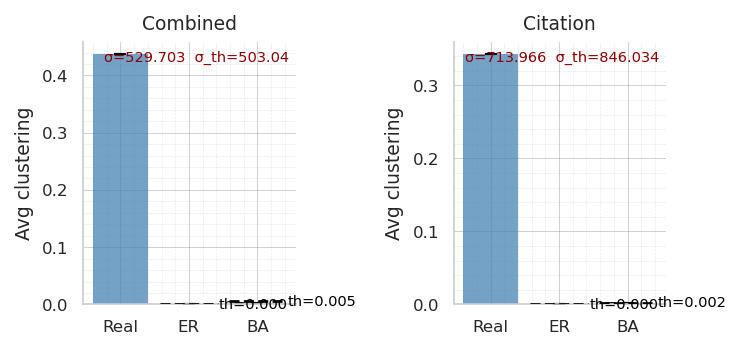

Fig 2: avg path vs null models


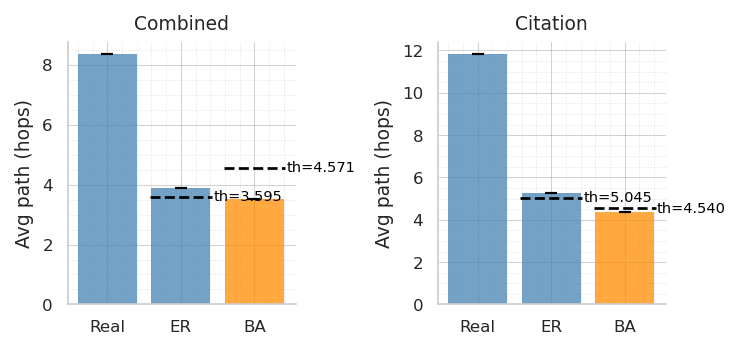

Fig 3: degree CCDF vs null models


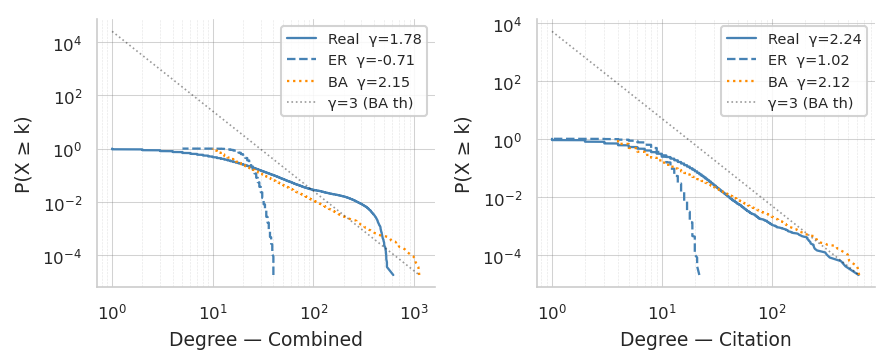

Null models released.


In [19]:
import math, gc, os
from scipy import stats as sp_stats
from collections import Counter

# ══════════════════════════════════════════════════════════════════
# CONFIG  — adatta questi nomi alle tue variabili del notebook
# ══════════════════════════════════════════════════════════════════

graph_configs = {
    'Combined': {
        'real':     lcc['bc_uw'],
        'avg_path': sp_bc['avg_path'],
        'diameter': sp_bc['diameter'],
    },
    'Citation': {
        'real':     lcc['cit_ud'],
        'avg_path': sp_cit['avg_path'],
        'diameter': sp_cit['diameter'],
    },
}

N_REP  = 1
N_SAMP = 500
SEED   = 42
NC     = {'Real': COLORS['bc_uw'], 'ER': 'steelblue', 'BA': 'darkorange'}
LINE   = {'Real': '-', 'ER': '--', 'BA': ':'}


# ══════════════════════════════════════════════════════════════════
# FORMULE TEORICHE  (Cap 3-4-5)
# ══════════════════════════════════════════════════════════════════

def _er_theory(G_real):
    """
    [Cap3]  p    = 2L / [N(N-1)]
    [Cap3]  C_ER = p = ⟨k⟩/N
    [Cap4]  ⟨d⟩  = ln N / ln⟨k⟩
    """
    N = G_real.number_of_nodes()
    L = G_real.number_of_edges()
    k = 2 * L / N
    p = (2 * L) / (N * (N - 1))
    return {
        'p':    p,
        'C_th': p,
        'd_th': math.log(N) / math.log(k) if k > 1 else float('inf'),
    }


def _ba_theory(G_real):
    """
    [Cap5]  m     = round(L/N)
    [Cap5]  C_BA  = (m/4) · (ln N)² / N
    [Cap5]  ⟨d⟩  ~ ln N / ln(ln N)   (ultra-small world, γ=3)
    """
    N   = G_real.number_of_nodes()
    L   = G_real.number_of_edges()
    m   = max(1, round(L / N))
    lnN = math.log(N)
    return {
        'm':    m,
        'C_th': (m / 4) * lnN**2 / N,
        'd_th': lnN / math.log(lnN) if lnN > 1 else float('inf'),
    }


def _fit_gamma(G):
    """[Cap5]  fit log-log p_k ~ k^{-γ}. Ritorna (γ, R²)."""
    degs = [d for _, d in G.degree() if d > 0]
    cnt  = Counter(degs)
    ks   = np.array(sorted(cnt), dtype=float)
    pk   = np.array([cnt[k] / len(degs) for k in ks])
    mask = (ks > 0) & (pk > 0)
    if mask.sum() < 3:
        return np.nan, np.nan
    s, _, r, _, _ = sp_stats.linregress(np.log(ks[mask]), np.log(pk[mask]))
    return round(-s, 3), round(r**2, 3)


# ══════════════════════════════════════════════════════════════════
# UTILITY
# ══════════════════════════════════════════════════════════════════

def _lcc(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()


def _path_sample(Lcc, seed, n=N_SAMP):
    nodes = list(Lcc.nodes())
    samp  = np.random.default_rng(seed).choice(
        nodes, size=min(n, len(nodes)), replace=False)
    ds = [d for v in samp
          for d in nx.single_source_shortest_path_length(Lcc, v).values()
          if d > 0]
    return float(np.mean(ds)), int(np.max(ds))


def _style_ax(ax, loglog=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


# ══════════════════════════════════════════════════════════════════
# NULL STATS  —  G(N,p) canonico [Cap3], BA [Cap5]
# ══════════════════════════════════════════════════════════════════

def null_stats(G_real, model='ER', n_rep=N_REP, seed=SEED):
    N  = G_real.number_of_nodes()
    M  = G_real.number_of_edges()
    m  = max(1, round(M / N))
    p_er = (2 * M) / (N * (N - 1))   # [Cap3] p corretto per G(N,p)

    th    = _er_theory(G_real) if model == 'ER' else _ba_theory(G_real)
    seeds = np.random.default_rng(seed).integers(0, 100_000, size=n_rep)
    clusterings, paths, graphs = [], [], []

    for s in seeds:
        G = (nx.erdos_renyi_graph(N, p_er, seed=int(s))        # [Cap3] G(N,p)
             if model == 'ER'
             else nx.barabasi_albert_graph(N, m, seed=int(s)))  # [Cap5] BA
        Lcc = _lcc(G)
        clusterings.append(nx.average_clustering(Lcc))
        avg_p, _ = _path_sample(Lcc, int(s))
        paths.append(avg_p)
        graphs.append(G)

    return {
        'clustering':     float(np.mean(clusterings)),
        'clustering_std': float(np.std(clusterings)),
        'clustering_th':  th['C_th'],   # baseline analitica
        'path':           float(np.mean(paths)),
        'path_std':       float(np.std(paths)),
        'path_th':        th['d_th'],   # baseline analitica
        'theory':         th,
        'last_graph':     graphs[-1],
    }


def real_stats(G_real, avg_path_exact, diameter_exact):
    Lcc = _lcc(G_real)
    return {
        'clustering':     nx.average_clustering(Lcc),
        'clustering_std': 0.0,
        'clustering_th':  None,
        'path':           avg_path_exact,
        'path_std':       0.0,
        'path_th':        None,
    }


# ══════════════════════════════════════════════════════════════════
# CALCOLO
# ══════════════════════════════════════════════════════════════════

print("Computing null model metrics …")
null_results = {}
for gname, meta in graph_configs.items():
    G_real = meta['real']
    print(f"  {gname} — ER ×{N_REP} …", end=' ', flush=True)
    er = null_stats(G_real, 'ER')
    print("done  | BA …", end=' ', flush=True)
    ba = null_stats(G_real, 'BA')
    print("done")
    null_results[gname] = {
        'Real': real_stats(G_real, meta['avg_path'], meta['diameter']),
        'ER':   er,
        'BA':   ba,
    }
print("All done.\n")


# ══════════════════════════════════════════════════════════════════
# σ  SMALL-WORLD INDEX  (empirico + teorico)
# ══════════════════════════════════════════════════════════════════

hdr = f"{'Graph':<12} {'σ_emp':>8} {'σ_th':>8}  {'C_real':>8} {'C_ER_th':>9}  {'d_real':>7} {'d_ER_th':>8}"
print(hdr)
print("─" * len(hdr))

for gname, res in null_results.items():
    Cr, Lr   = res['Real']['clustering'], res['Real']['path']
    Ce, Le   = res['ER']['clustering'],   res['ER']['path']
    Ce_th    = res['ER']['clustering_th']
    Le_th    = res['ER']['path_th']

    s_emp = round((Cr / Ce)    / (Lr / Le),    3) if Ce    > 0 and Le    > 0 else '—'
    s_th  = round((Cr / Ce_th) / (Lr / Le_th), 3) if Ce_th > 0 and Le_th > 0 else '—'

    null_results[gname]['sigma']    = s_emp
    null_results[gname]['sigma_th'] = s_th
    print(f"  {gname:<10} {str(s_emp):>8} {str(s_th):>8}  "
          f"{Cr:>8.4f} {Ce_th:>9.4f}  {Lr:>7.3f} {Le_th:>8.3f}")


# ══════════════════════════════════════════════════════════════════
# TABELLA RIASSUNTIVA
# ══════════════════════════════════════════════════════════════════

import pandas as pd
for gname, res in null_results.items():
    rows = []
    for model in ['Real', 'ER', 'BA']:
        r = res[model]
        rows.append({
            'Model':      model,
            'Clustering': f"{r['clustering']:.4f} ± {r['clustering_std']:.4f}",
            'Avg path':   f"{r['path']:.3f} ± {r['path_std']:.3f}",
        })
    print(f"\n{gname} vs null models")
    print(pd.DataFrame(rows).set_index('Model').to_string())


# ══════════════════════════════════════════════════════════════════
# HELPER PLOT
# ══════════════════════════════════════════════════════════════════

def _bar_trio(ax, res, ylabel, key):
    """Barre empiriche + linea tratteggiata = valore analitico teorico."""
    models = ['Real', 'ER', 'BA']
    means  = [res[m][key]          for m in models]
    stds   = [res[m][f'{key}_std'] for m in models]

    ax.bar(models, means, yerr=stds,
           color=[NC[m] for m in models], alpha=0.75,
           edgecolor='none', capsize=3,
           error_kw=dict(elinewidth=0.8, ecolor='black'))

    for i, model in enumerate(models):
        th_val = res[model].get(f'{key}_th')
        if th_val is not None:
            ax.hlines(th_val, i - 0.42, i + 0.42,
                      colors='black', linewidths=1.3,
                      linestyles='--', zorder=5)
            ax.text(i + 0.44, th_val, f'th={th_val:.3f}',
                    va='center', fontsize=7, color='black')

    ax.set_ylabel(ylabel)
    _style_ax(ax)


def _ccdf(G):
    d = sorted([k for _, k in G.degree() if k > 0], reverse=True)
    return np.array(d), np.arange(1, len(d) + 1) / G.number_of_nodes()


# ══════════════════════════════════════════════════════════════════
# FIG 1 — Clustering
# ══════════════════════════════════════════════════════════════════

print("\nFig 1: clustering vs null models")
fig, axes = plt.subplots(1, 2, figsize=(5, 2.4))
for ax, (gname, res) in zip(axes, null_results.items()):
    _bar_trio(ax, res, 'Avg clustering', 'clustering')
    ax.set_title(gname, fontsize=9)
    sig    = res.get('sigma')
    sig_th = res.get('sigma_th')
    ax.text(0.97, 0.97, f'σ={sig}  σ_th={sig_th}',
            transform=ax.transAxes, fontsize=7,
            ha='right', va='top', color='darkred')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_clustering.png'), dpi=200, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════
# FIG 2 — Avg Path
# ══════════════════════════════════════════════════════════════════

print("Fig 2: avg path vs null models")
fig, axes = plt.subplots(1, 2, figsize=(5, 2.4))
for ax, (gname, res) in zip(axes, null_results.items()):
    _bar_trio(ax, res, 'Avg path (hops)', 'path')
    ax.set_title(gname, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'null_path.png'), dpi=200, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════
# FIG 3 — CCDF + γ fittato + riferimento γ=3
# ══════════════════════════════════════════════════════════════════

print("Fig 3: degree CCDF vs null models")
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
for ax, (gname, meta) in zip(axes, graph_configs.items()):
    res = null_results[gname]
    for model, G in [('Real', meta['real']),
                     ('ER',   res['ER']['last_graph']),
                     ('BA',   res['BA']['last_graph'])]:
        x, y = _ccdf(G)
        gamma_fit, r2 = _fit_gamma(G)
        lbl = f"{model}  γ={gamma_fit:.2f}" if not np.isnan(gamma_fit) else model
        ax.loglog(x, y, color=NC[model], lw=1.1, ls=LINE[model], label=lbl)

    # riferimento γ=3 BA teorico [Cap5]
    x_ref = np.logspace(0, np.log10(x.max()), 80)
    c_ref = y[0] * x[0]**3
    ax.loglog(x_ref, c_ref * x_ref**(-3), 'k:', lw=0.8, alpha=0.4, label='γ=3 (BA th)')

    ax.set_xlabel(f'Degree — {gname}')
    ax.set_ylabel('P(X ≥ k)')
    ax.legend(fontsize=7, framealpha=0.85)
    _style_ax(ax, loglog=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_vs_null.png'), dpi=200, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════
# CLEANUP
# ══════════════════════════════════════════════════════════════════

for res in null_results.values():
    for model in ['ER', 'BA']:
        del res[model]['last_graph']
gc.collect()
print("Null models released.")

Computing strength and weighted clustering ...
         Weighted clustering  Unweighted clustering
Metric                                             
Mean                  0.1575                 0.4312
Median                0.1315                 0.4145
Std                   0.1328                 0.2817
C=0 (%)              14.3961                14.3961
C=1 (%)               0.0358                 7.1179

Spearman weighted vs unweighted clustering: ρ=0.9155
Spearman degree vs strength: ρ=0.9608
Top-10 degree ∩ strength: 3/10

Weight by degree tertile:
  Group              Edges    Mean  Median     P90
  Low degree        56,472  0.3743  0.3500  0.6500
  Mid degree       192,289  0.3622  0.3500  0.6500
  High degree      931,553  0.2814  0.2110  0.5520

Fig: hub dilution + weighted clustering.


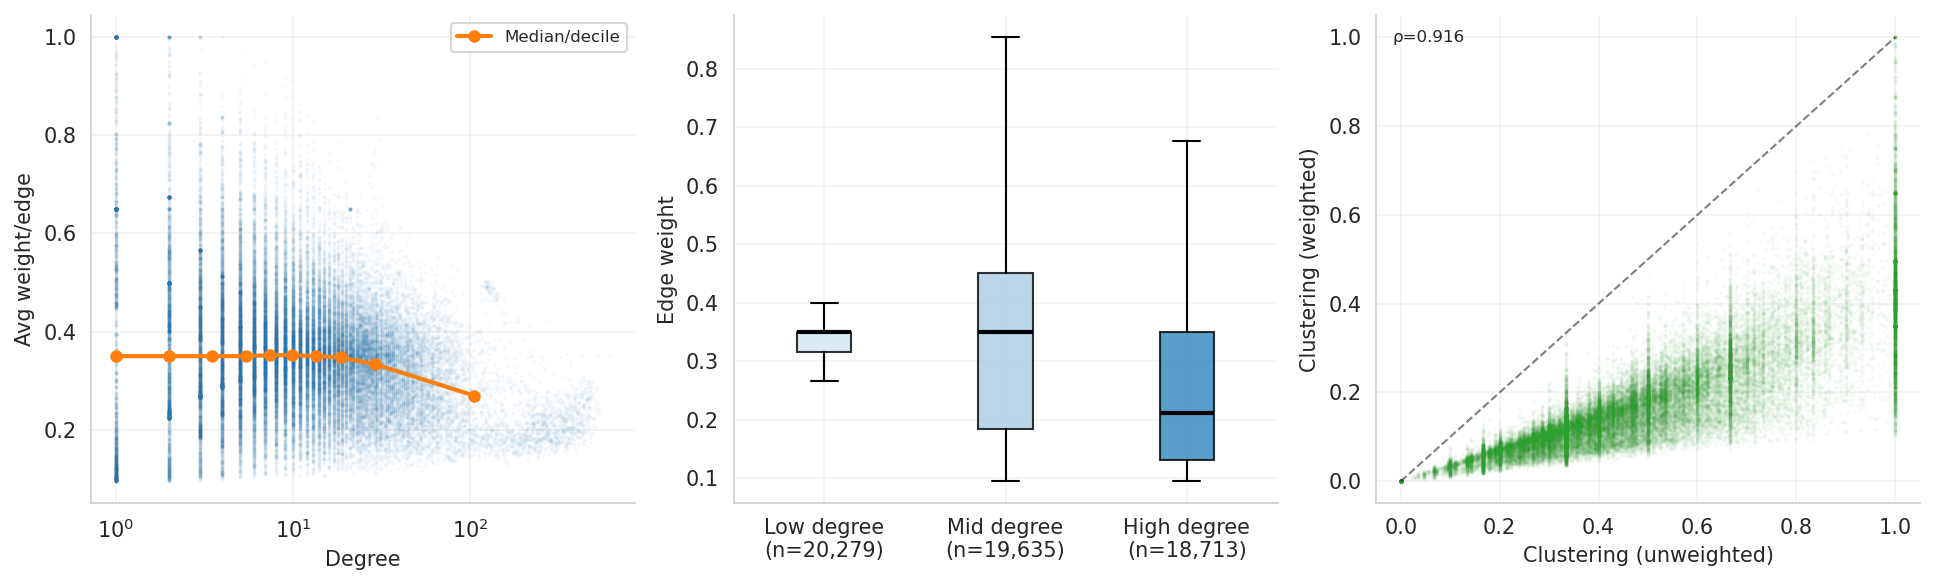

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams.update({
    'font.size': 9, 'axes.labelsize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

def _style_ax(ax, loglog=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    if loglog:
        ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

rng = np.random.default_rng(42)

def _jitter(v, x_center, width=0.12):
    return x_center + rng.uniform(-width, width, len(v))


print("Fig: hub dilution + violin weight by degree + clustering scatter.")

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))


# ── ax0: hub dilution scatter + mediana per decile ───────────────────────────
ax = axes[0]
ax.scatter(xd, yw, alpha=0.04, s=2, color=COLORS['bc_uw'], lw=0)
ax.plot(bx, bm, marker='o', ms=3.5, color='saddlebrown',
        lw=1, label='Median/decile')
ax.set_xscale('log')
ax.set_xlabel('Degree')
ax.set_ylabel('Avg weight / edge')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, loglog=False)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))


# ── ax1: violin + jitter peso per terzile di degree ─────────────────────────
ax = axes[1]
group_names  = list(groups.keys())
group_colors = ['#a8c8e8', '#5a9fc0', '#1a5f7a']

parts = ax.violinplot(
    [np.array(ew[g]) for g in group_names],
    positions=[1, 2, 3],
    showmedians=True,
    showextrema=False,
    widths=0.5,
)
for body, color in zip(parts['bodies'], group_colors):
    body.set_facecolor(color)
    body.set_alpha(0.3)
    body.set_edgecolor(color)
    body.set_linewidth(0.8)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.2)

for i, (g, color) in enumerate(zip(group_names, group_colors), start=1):
    vals = np.array(ew[g])
    sample = vals if len(vals) <= 3000 else rng.choice(vals, 3000, replace=False)
    ax.scatter(_jitter(sample, i), sample,
               color=color, alpha=0.15, s=1.5, lw=0, zorder=2)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(
    [f"{g}\n(n={len(groups[g]):,})" for g in group_names],
    fontsize=7)
ax.set_ylabel('Edge weight')
_style_ax(ax)


# ── ax2: scatter clustering weighted vs unweighted ───────────────────────────
ax = axes[2]
uw_vals = np.array([clust_uw_full[n] for n in c_common])
ww_vals = np.array([clust_w[n]       for n in c_common])
ax.scatter(uw_vals, ww_vals,
           alpha=0.06, s=2, color=COLORS['cit_ud'], lw=0)
ax.plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Clustering (unweighted)')
ax.set_ylabel('Clustering (weighted)')
ax.text(0.97, 0.05, fr'$\rho={rho_c:.3f}$',
        transform=ax.transAxes, fontsize=8,
        ha='right', va='bottom')
_style_ax(ax)


plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'weighted_analysis.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [26]:
print("Computing directed metrics ...")
in_deg  = dict(G_cit_d.in_degree()); out_deg = dict(G_cit_d.out_degree())
pagerank = nx.pagerank(G_cit_d, alpha=0.85, max_iter=200, tol=1e-6)
recip = nx.reciprocity(G_cit_d)
n_recip = sum(1 for u,v in G_cit_d.edges() if G_cit_d.has_edge(v,u))
print(f"  Reciprocity: {recip:.6f} ({n_recip:,} / {G_cit_d.number_of_edges():,} = {n_recip/G_cit_d.number_of_edges()*100:.2f}%)")

iv=np.array(list(in_deg.values())); ov=np.array(list(out_deg.values())); pv=np.array(list(pagerank.values()))
df_dir = pd.DataFrame({l:[f(a) for _,f in fns] for l,a in [('In-degree',iv),('Out-degree',ov),('PageRank',pv)]},
    index=[n for n,_ in fns])
print("\nDirected metrics\n"); print(df_dir.to_string(float_format=lambda x:f'{x:.6f}'))

cd=list(set(in_deg)&set(out_deg)&set(pagerank))
for l,x,y in [('PR vs In',pagerank,in_deg),('In vs Out',in_deg,out_deg)]:
    r,p=spearmanr([x[n] for n in cd],[y[n] for n in cd])
    print(f"  Spearman {l}: ρ={r:.4f}  p={'<0.001' if p<.001 else f'{p:.3f}'}")

# Prestige vs popularity
mx_pr,mx_in=max(pv),max(iv)
delta={n: pagerank[n]/mx_pr - in_deg[n]/mx_in for n in cd}

Computing directed metrics ...
  Reciprocity: 0.006892 (1,502 / 217,925 = 0.69%)

Directed metrics

        In-degree  Out-degree  PageRank
Mean     3.956661    3.956661  0.000018
Std      8.581076    4.817520  0.000032
Median   2.000000    2.000000  0.000010
Max    616.000000  128.000000  0.002243
P90     10.000000   10.000000  0.000034
P99     28.000000   22.000000  0.000138
  Spearman PR vs In: ρ=0.9036  p=<0.001
  Spearman In vs Out: ρ=0.0900  p=<0.001



Fig: directed analysis.


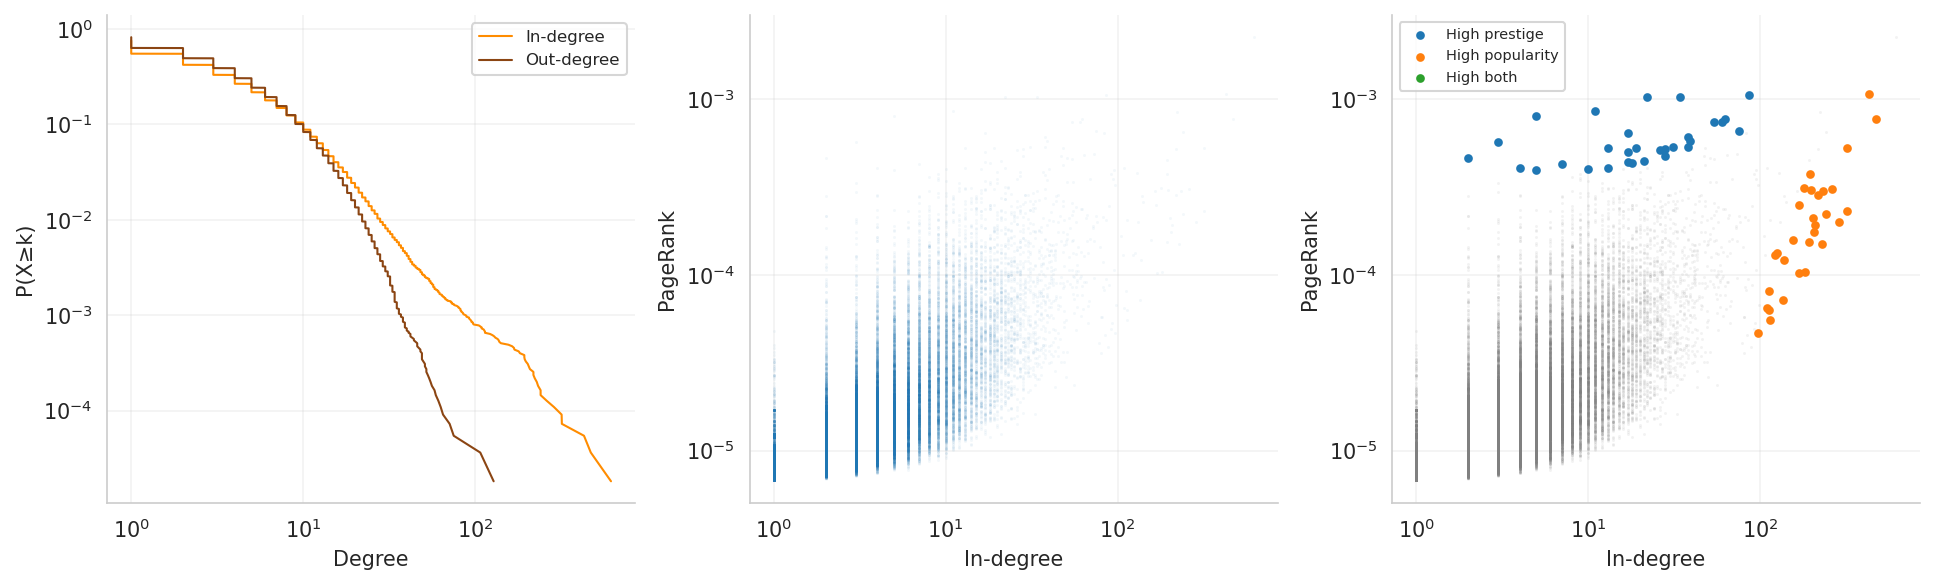

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams.update({
    'font.size': 9, 'axes.labelsize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

def _style_ax(ax, loglog=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    if loglog:
        ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


print("\nFig: directed analysis.")

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))


# ── ax0: CCDF in- vs out-degree ───────────────────────────────────────────────
ax = axes[0]
for a, color, label in [
    (iv, COLORS['cit_d'],  'In-degree'),
    (ov, 'saddlebrown',    'Out-degree'),
]:
    s = np.sort(a[a > 0])[::-1]
    ax.loglog(s, np.arange(1, len(s) + 1) / len(a),
              color=color, lw=1, label=label)
ax.set_xlabel('Degree')
ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, loglog=True)


# ── ax1: scatter in-degree vs PageRank ───────────────────────────────────────
ax = axes[1]
ax.scatter(list(in_deg.values()), list(pagerank.values()),
           alpha=0.05, s=2, color=COLORS['cit_d'], lw=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('In-degree')
ax.set_ylabel('PageRank')
_style_ax(ax, loglog=True)


# ── ax2: scatter con highlight prestige / popularity ─────────────────────────
ax = axes[2]

top_pr   = {n for n, _ in sorted(delta.items(), key=lambda x: -x[1])[:30]}
top_po   = {n for n, _ in sorted(delta.items(), key=lambda x:  x[1])[:30]}
top_both = top_pr & top_po

# background — tutti i nodi
ax.scatter([in_deg[n] for n in cd],
           [pagerank[n] for n in cd],
           alpha=0.08, s=2, color='gray', lw=0, zorder=1)

# highlight — ordine: both sopra
for nodes, color, label in [
    (top_pr,   COLORS['cit_d'],  'High prestige'),
    (top_po,   'saddlebrown',    'High popularity'),
    (top_both, COLORS['bc_uw'],  'High both'),
]:
    if nodes:
        ax.scatter([in_deg[n] for n in nodes],
                   [pagerank[n] for n in nodes],
                   s=12, color=color, lw=0, zorder=3, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('In-degree')
ax.set_ylabel('PageRank')
ax.legend(fontsize=7, framealpha=0.85,
          markerscale=1.2, handletextpad=0.4)
_style_ax(ax, loglog=True)


plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'directed_analysis.png'),
            dpi=200, bbox_inches='tight')
plt.show()

Computing assortativity ...
                       Assortativity        Trend
Graph                                            
Combined (weighted)         0.814133  assortative
Combined (unweighted)       0.814133  assortative
Citation (undirected)       0.055164  assortative
Citation (directed)         0.120782  assortative

Computing k-core ...
                     Combined  Citation
Metric                                 
Max k-core             188.00     21.00
Mean k-core             12.48      4.96
Median k-core            7.00      4.00
Nodes in max k-core    211.00     38.00
% in max k-core          0.38      0.08

Fig: assortativity + k-core.


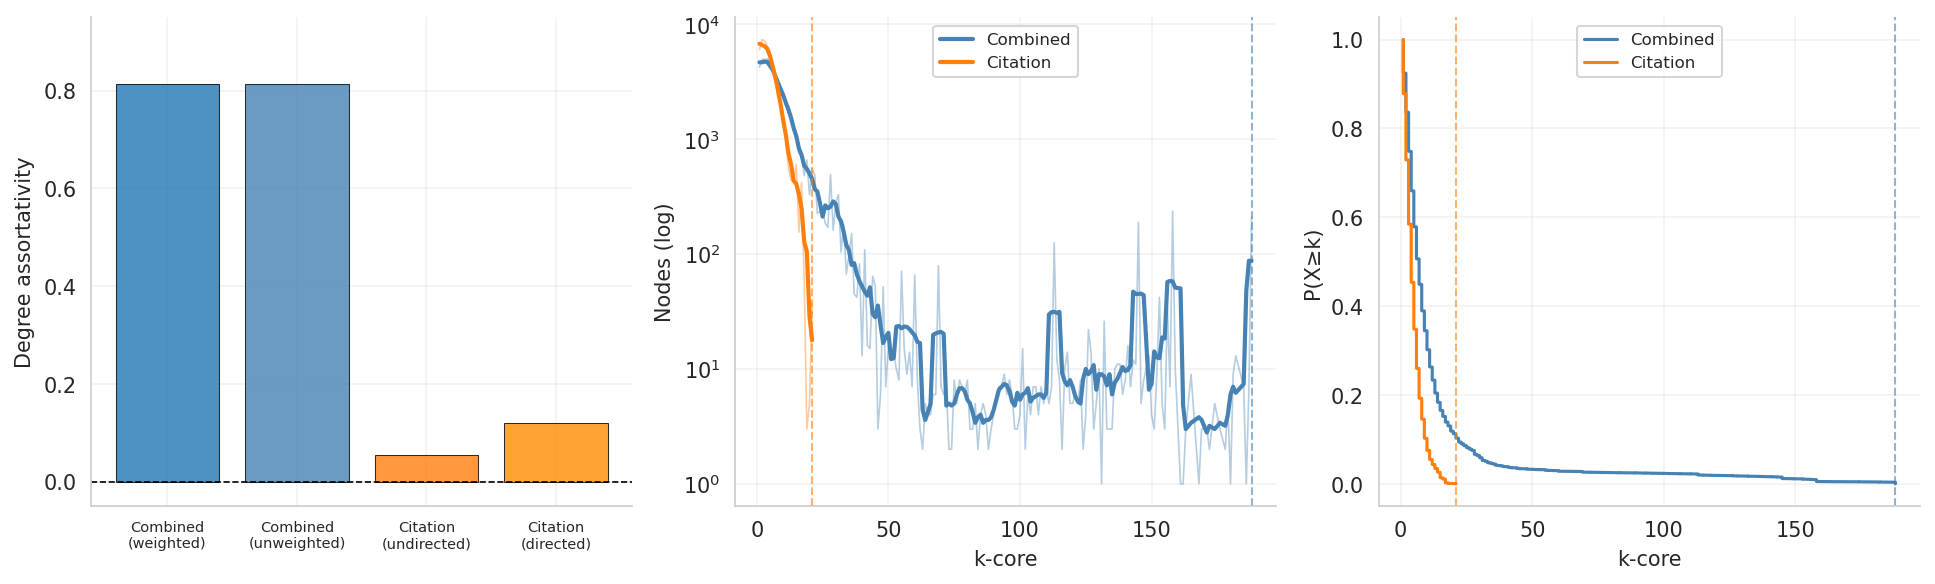

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from collections import Counter
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({
    'font.size': 9, 'axes.labelsize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

def _style_ax(ax, loglog=False, semilogy=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    if loglog:
        ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    elif semilogy:
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


print("\nFig: assortativity + k-core.")

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))


# ── ax0: barplot assortativity ────────────────────────────────────────────────
ax = axes[0]
gl = [NAMES[k] for k in graphs]
gv = [assort[k] for k in graphs]
gc_ = [COLORS[k] for k in graphs]

ax.bar(range(len(gl)), gv,
       color=gc_, alpha=0.75, edgecolor='none', lw=0)
ax.set_xticks(range(len(gl)))
ax.set_xticklabels([n.replace(' ', '\n') for n in gl], fontsize=7)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_ylabel('Degree assortativity')
ax.set_ylim(-0.05, max(gv) * 1.15)
_style_ax(ax)


# ── ax1: distribuzione k-core (semilogy) ─────────────────────────────────────
ax = axes[1]
for kv, color, label in [
    (kv_bc,  COLORS['bc_uw'],  'Combined'),
    (kv_cit, COLORS['cit_ud'], 'Citation'),
]:
    cnt = Counter(kv)
    ks  = np.array(sorted(cnt))
    ns  = np.array([cnt[k] for k in ks], dtype=float)
    # linea grezza semitrasparente + smoothed
    ax.semilogy(ks, ns, color=color, lw=0.8, alpha=0.35)
    if len(ns) > 10:
        ax.semilogy(ks, uniform_filter1d(ns, 5),
                    color=color, lw=1.2, label=label)
    else:
        ax.semilogy(ks, ns, color=color, lw=1.2,
                    marker='s', ms=3, label=label)

ax.axvline(km_bc,  color=COLORS['bc_uw'],  lw=0.8, ls='--', alpha=0.6)
ax.axvline(km_cit, color=COLORS['cit_ud'], lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('k-core')
ax.set_ylabel('Nodes')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax, semilogy=True)


# ── ax2: CCDF k-core ──────────────────────────────────────────────────────────
ax = axes[2]
for kv, color, label in [
    (kv_bc,  COLORS['bc_uw'],  'Combined'),
    (kv_cit, COLORS['cit_ud'], 'Citation'),
]:
    s = np.sort(kv)[::-1]
    ax.plot(s, np.arange(1, len(s) + 1) / len(s),
            color=color, lw=1, label=label)

ax.axvline(km_bc,  color=COLORS['bc_uw'],  lw=0.8, ls='--', alpha=0.6)
ax.axvline(km_cit, color=COLORS['cit_ud'], lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('k-core')
ax.set_ylabel('P(X ≥ k)')
ax.legend(fontsize=7, framealpha=0.85)
_style_ax(ax)


plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'assortativity_kcore.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [15]:
summary = {
    NAMES['bc_w']: {
        'Nodes': G_combined_w.number_of_nodes(), 'Edges': G_combined_w.number_of_edges(),
        'Avg degree': round(np.mean([d for _,d in G_combined_w.degree()]),2),
        'Avg strength': round(np.mean(str_vals),4),
        'Density': round(nx.density(G_combined_w),6),
        'LCC (%)': round(lcc['bc_w'].number_of_nodes()/G_combined_w.number_of_nodes()*100,1),
        'Clustering (uw)':'—', 'Clustering (w)': round(np.mean(clust_w_v),4),
        'Avg path':'—', 'Diameter':'—', 'σ':'—',
        'Assortativity': round(assort['bc_w'],4), 'Max k-core':'—', 'Reciprocity':'—'},
    NAMES['bc_uw']: {
        'Nodes': lcc['bc_uw'].number_of_nodes(), 'Edges': lcc['bc_uw'].number_of_edges(),
        'Avg degree': round(np.mean(deg_bc),2), 'Avg strength':'—',
        'Density': round(nx.density(lcc['bc_uw']),6),
        'LCC (%)': round(lcc['bc_uw'].number_of_nodes()/G_combined_uw.number_of_nodes()*100,1),
        'Clustering (uw)': round(clust_bc_m,4), 'Clustering (w)':'—',
        'Avg path': round(sp_bc['avg_path'],3), 'Diameter': int(sp_bc['diameter']),
        'σ': r_bc[0].get('σ','—'),
        'Assortativity': round(assort['bc_uw'],4), 'Max k-core': int(km_bc), 'Reciprocity':'—'},
    NAMES['cit_ud']: {
        'Nodes': lcc['cit_ud'].number_of_nodes(), 'Edges': lcc['cit_ud'].number_of_edges(),
        'Avg degree': round(np.mean(deg_cit),2), 'Avg strength':'—',
        'Density': round(nx.density(lcc['cit_ud']),6),
        'LCC (%)': round(lcc['cit_ud'].number_of_nodes()/G_cit_ud.number_of_nodes()*100,1),
        'Clustering (uw)': round(clust_cit_m,4), 'Clustering (w)':'—',
        'Avg path': round(sp_cit['avg_path'],3), 'Diameter': int(sp_cit['diameter']),
        'σ': r_cit[0].get('σ','—'),
        'Assortativity': round(assort['cit_ud'],4), 'Max k-core': int(km_cit), 'Reciprocity':'—'},
    NAMES['cit_d']: {
        'Nodes': G_cit_d.number_of_nodes(), 'Edges': G_cit_d.number_of_edges(),
        'Avg degree': round(np.mean(iv+ov)/2,2), 'Avg strength':'—',
        'Density': round(nx.density(G_cit_d),6),
        'LCC (%)': round(cc_dir['LCC(WCC)%'],1),
        'Clustering (uw)':'—', 'Clustering (w)':'—',
        'Avg path':'—', 'Diameter':'—', 'σ':'—',
        'Assortativity': round(assort['cit_d'],4), 'Max k-core':'—', 'Reciprocity': round(recip,6)},
}
df_sum = pd.DataFrame(summary).T
print("Summary\n"); print(df_sum.to_string())
df_sum.to_csv(os.path.join(out_dir, 'summary_metrics.csv'))
print(f"\nSaved to {out_dir}/summary_metrics.csv")

Summary

                       Nodes   Edges Avg degree Avg strength   Density LCC (%) Clustering (uw) Clustering (w) Avg path Diameter       σ Assortativity Max k-core Reciprocity
Combined (weighted)    58627  590157      20.13       6.0192  0.000343    95.6               —         0.1575        —        —       —        0.8141          —           —
Combined (unweighted)  56045  586866      20.94            —  0.000374    95.6          0.4366              —    8.349       49   507.9        0.8141        188           —
Citation (undirected)  49243  209599       8.51            —  0.000173    89.4          0.3424              —    11.81       48  768.01        0.0552         21           —
Citation (directed)    55078  217925       3.96            —  0.000072    89.4               —              —        —        —       —        0.1208          —    0.006892

Saved to ./output/summary_metrics.csv


Cross-metric summary by node role (Combined LCC):

  Role                      N  Deg(mean)  Betw(mean)  Clos(mean)  Str(mean)
--------------------------------------------------------------------------
  Global Hub              330     118.85    0.001882    0.150989    35.0411
  Local Hub               790     190.44    0.000011    0.137738    43.2534
  Strategic Bridge        369       6.47    0.001160    0.123182     2.0800
  Intermediate         14,692      22.86    0.000140    0.130083     7.5314
  Uncategorized        39,864      16.20    0.000106    0.119213     4.8284

Fig: closeness distribution by role.


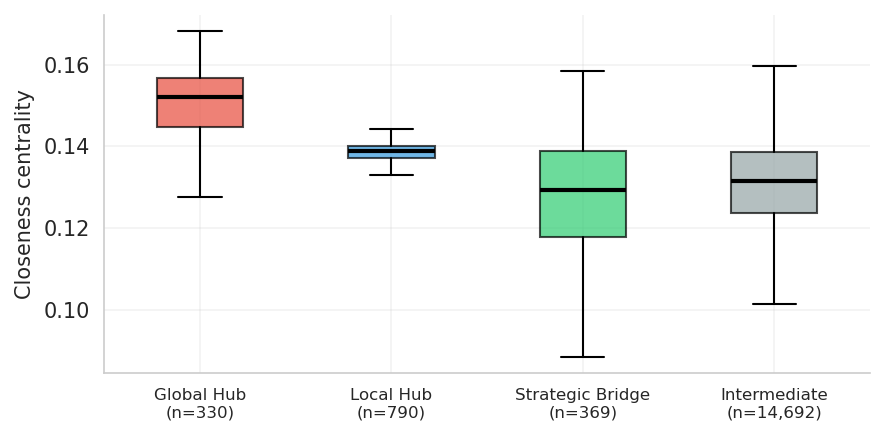

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Role classification — cross-metric summary
# ══════════════════════════════════════════════════════════════════════════════

print("Cross-metric summary by node role (Combined LCC):\n")
print(f"  {'Role':<20} {'N':>6} {'Deg(mean)':>10} {'Betw(mean)':>11} "
      f"{'Clos(mean)':>11} {'Str(mean)':>10}")
print("-" * 74)

for role in ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate', 'Uncategorized']:
    nodes_r = [n for n, r in roles.items() if r == role]
    if not nodes_r:
        continue
    d_v = np.array([deg_c_bc.get(n, 0) for n in nodes_r])
    b_v = np.array([betw_bc.get(n, 0)  for n in nodes_r])
    c_v = np.array([clos_bc.get(n, 0)  for n in nodes_r])
    s_v = np.array([strength.get(n, 0) for n in nodes_r])
    print(f"  {role:<20} {len(nodes_r):>6,} {d_v.mean():>10.2f} {b_v.mean():>11.6f} "
          f"{c_v.mean():>11.6f} {s_v.mean():>10.4f}")

print("\nFig: closeness distribution by role.")
fig, ax = plt.subplots(figsize=(6, 3))
role_order = ['Global Hub', 'Local Hub', 'Strategic Bridge', 'Intermediate']
role_data = []
role_labels = []
for role in role_order:
    nodes_r = [n for n, r in roles.items() if r == role and n in clos_bc]
    if nodes_r:
        role_data.append([clos_bc[n] for n in nodes_r])
        role_labels.append(f"{role}\n(n={len(nodes_r):,})")

bp = ax.boxplot(role_data, tick_labels=role_labels, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', lw=2))
colors_role = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
for patch, c in zip(bp['boxes'], colors_role[:len(role_data)]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('Closeness centrality')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'closeness_by_role.png'), bbox_inches='tight')
plt.show()